# Laboratorio 7 -- Spark MLlib sobre la ENEIC

Universidad del Valle de Guatemala. CC3084 Data Science, Semestre II 2026.

Fernando Rueda -- 23748. Fernando Hernández -- 23645.

Trabajamos con las bases de Personas de la Encuesta Nacional de Empleo e Ingresos Continua
del INE. Los cuatro trimestres de 2025 sirven para el desarrollo de los modelos y el primer
trimestre de 2026 queda reservado para la evaluación final. Queremos responder dos
preguntas, qué perfiles de trabajadores asalariados se pueden identificar y qué tan bien se
puede estimar su salario mensual con características personales y laborales. Las
asociaciones que encontremos no son causales ni recomendaciones sobre cuánto debería ganar
una persona.

Spark no lee Excel de forma nativa, así que leemos cada archivo con pandas, lo convertimos a
un DataFrame de Spark con tipos explícitos y desde ahí toda la preparación y el aprendizaje
automático se hacen con Spark. Solo pasamos a pandas tablas agregadas o muestras pequeñas
para graficar.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import load_workbook

# Java 17 local si no viene definido en el entorno
if "JAVA_HOME" not in os.environ:
    os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"
# los workers de Spark deben usar el mismo Python que el kernel
os.environ.setdefault("PYSPARK_PYTHON", sys.executable)

from pyspark.sql import SparkSession, functions as F, types as T

spark = (SparkSession.builder.master("local[*]").appName("lab7-eneic")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.execution.arrow.pyspark.enabled", "true")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

ROOT = Path.cwd()
while not (ROOT / ".git").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RAW = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"
PROC.mkdir(parents=True, exist_ok=True)
SEMILLA = 23748
sns.set_theme(style="whitegrid")
print("Spark", spark.version)

26/09/24 19:34:43 WARN Utils: Your hostname, Fernandos-MacBook-Pro.local resolves to a loopback address: 127.0.0.1; using 192.168.1.54 instead (on interface en0)
26/09/24 19:34:43 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/24 19:34:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.1


## Ejercicio 1. Carga, armonización y calidad de datos

### Procedencia de los archivos

Los cinco archivos son las bases de Personas publicadas por el INE en
https://www.ine.gob.gt/encuesta-nacional-de-empleo-e-ingresos/, junto con su diccionario de
datos. La descarga se hace con la celda siguiente, que solo baja lo que falte. Cada archivo
recibe un periodo_archivo que identifica el corte publicado al que pertenece y un
archivo_origen para la trazabilidad. Conservamos TRIMESTRE tal como viene, pero no lo usamos
como trimestre calendario, porque en el archivo del primer trimestre de 2025 vale 2 y en el
del segundo trimestre aparece 3 y, en 175 registros, 2. Restarle uno no resolvería todos los
casos.

In [2]:
import urllib.request

BASE = "https://www.ine.gob.gt/wp-content/uploads/"
ARCHIVOS = {
    # periodo_archivo: (archivo local, ruta en el sitio del INE)
    "2025-I":   ("personas_2025_I.xlsx",   "2026/01/Personas_ENEIC_T1_2025.xlsx"),
    "2025-II":  ("personas_2025_II.xlsx",  "2026/01/Personas-ENEIC-T2-2025.xlsx"),
    "2025-III": ("personas_2025_III.xlsx", "2026/05/Base-de-datos-Personas-ENEIC-III-2025.xlsx"),
    "2025-IV":  ("personas_2025_IV.xlsx",  "2026/06/Base-de-datos-Personas-ENEIC-IV-2025.xlsx"),
    "2026-I":   ("personas_2026_I.xlsx",   "2026/09/Base-de-datos-Personas-ENEIC-I-2026.xlsx"),
}
RAW.mkdir(parents=True, exist_ok=True)
for periodo, (local, remoto) in ARCHIVOS.items():
    destino = RAW / local
    if not destino.exists():
        req = urllib.request.Request(BASE + remoto, headers={"User-Agent": "Mozilla/5.0"})
        destino.write_bytes(urllib.request.urlopen(req).read())
    print(f"{periodo:9s} {local:26s} {destino.stat().st_size / 1e6:6.1f} MB")

2025-I    personas_2025_I.xlsx         47.7 MB
2025-II   personas_2025_II.xlsx        16.9 MB
2025-III  personas_2025_III.xlsx       47.6 MB
2025-IV   personas_2025_IV.xlsx        51.3 MB
2026-I    personas_2026_I.xlsx         46.0 MB


### Columnas del archivo IV de 2025

Antes de leer los datos revisamos el encabezado de cada archivo. El archivo IV de 2025 tiene
302 columnas y los demás 270, y además el orden cambia desde la octava columna, así que
apilar por posición mezclaría variables distintas bajo el mismo nombre.

In [3]:
encabezados = {}
for periodo, (local, _) in ARCHIVOS.items():
    ws = load_workbook(RAW / local, read_only=True).worksheets[0]
    encabezados[periodo] = [c.value for c in next(ws.iter_rows(max_row=1))]
    print(f"{periodo:9s} columnas: {len(encabezados[periodo])}")

ref, iv = encabezados["2025-I"], encabezados["2025-IV"]
distinta = next(i for i, (a, b) in enumerate(zip(ref, iv)) if a != b)
print(f"\nprimera posición distinta entre I-2025 e IV-2025: {distinta}"
      f" ({ref[distinta]} frente a {iv[distinta]})")
print("columnas que solo tiene IV-2025:", len(set(iv) - set(ref)))
print("columnas de I-2025 ausentes en IV-2025:", sorted(set(ref) - set(iv)))

2025-I    columnas: 270
2025-II   columnas: 270
2025-III  columnas: 270
2025-IV   columnas: 302
2026-I    columnas: 270

primera posición distinta entre I-2025 e IV-2025: 7 (P02A01C frente a P02A02)
columnas que solo tiene IV-2025: 42
columnas de I-2025 ausentes en IV-2025: ['P02A01C', 'P02A01D', 'P02A01G', 'P02A01I', 'P05C01A', 'P05C02A', 'P05C04A', 'P05G01A', 'P05G02A', 'P05G04A']


### Selección de columnas y homologación de tipos

Leemos de cada archivo solo las columnas que pide el laboratorio. Un mismo código puede
llegar como número o como texto, por ejemplo el diccionario del IV de 2025 trae los códigos
como texto, así que convertimos las variables categóricas a un entero nullable y las
numéricas a double antes de unir. Así los cinco DataFrames de Spark comparten exactamente el
mismo esquema.

In [4]:
COLUMNAS = ["ANIO", "TRIMESTRE", "DOMINIO", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
            "OCUPADOS", "P02A03", "P03A03A", "P05C07A", "P05C07B", "P05C16",
            "P05H01A", "P05D01"]
CODIGOS = ["ANIO", "TRIMESTRE", "DOMINIO", "NUM_HOGAR", "NUM_PERSONA",
           "OCUPADOS", "P03A03A", "P05C16"]
NUMERICAS = ["FACTOR", "P02A03", "P05C07A", "P05C07B", "P05H01A", "P05D01"]

ESQUEMA = T.StructType(
    [T.StructField("periodo_archivo", T.StringType()),
     T.StructField("archivo_origen", T.StringType())]
    + [T.StructField(c, T.IntegerType()) for c in CODIGOS]
    + [T.StructField(c, T.DoubleType()) for c in NUMERICAS])


def a_codigo(serie):
    # "1", 1 y 1.0 terminan igual; lo que no es número queda nulo
    return pd.to_numeric(serie.astype("string").str.strip(), errors="coerce").round().astype("Int64")


def leer_archivo(periodo, local):
    pdf = pd.read_excel(RAW / local, usecols=COLUMNAS)
    for c in CODIGOS:
        pdf[c] = a_codigo(pdf[c])
    for c in NUMERICAS:
        pdf[c] = pd.to_numeric(pdf[c], errors="coerce").astype("float64")
    pdf.insert(0, "archivo_origen", local)
    pdf.insert(0, "periodo_archivo", periodo)
    pdf = pdf[[f.name for f in ESQUEMA.fields]].astype(object).where(pdf.notna(), None)
    return spark.createDataFrame(pdf, schema=ESQUEMA)


crudos = {p: leer_archivo(p, local) for p, (local, _) in ARCHIVOS.items()}
for p, sdf in crudos.items():
    print(f"{p:9s} registros: {sdf.count():,}")

2025-I    registros: 51,588
2025-II   registros: 51,167


2025-III  registros: 51,583
2025-IV   registros: 49,338
2026-I    registros: 49,843


### Unión de 2025 con unionByName

Unimos los cuatro trimestres de 2025 por nombre de columna. El primer trimestre de 2026 se
mantiene aparte porque es el conjunto de prueba final.

In [5]:
from functools import reduce

periodos_2025 = ["2025-I", "2025-II", "2025-III", "2025-IV"]
crudo_2025 = reduce(lambda a, b: a.unionByName(b), [crudos[p] for p in periodos_2025])
crudo_2026 = crudos["2026-I"]

crudo_2025.printSchema()
crudo_2025.show(5, truncate=False)
print("registros 2025 unidos:", crudo_2025.count())

root
 |-- periodo_archivo: string (nullable = true)
 |-- archivo_origen: string (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- DOMINIO: integer (nullable = true)
 |-- NUM_HOGAR: integer (nullable = true)
 |-- NUM_PERSONA: integer (nullable = true)
 |-- OCUPADOS: integer (nullable = true)
 |-- P03A03A: integer (nullable = true)
 |-- P05C16: integer (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- P02A03: double (nullable = true)
 |-- P05C07A: double (nullable = true)
 |-- P05C07B: double (nullable = true)
 |-- P05H01A: double (nullable = true)
 |-- P05D01: double (nullable = true)



+---------------+--------------------+----+---------+-------+---------+-----------+--------+-------+------+------+------+-------+-------+-------+------+
|periodo_archivo|archivo_origen      |ANIO|TRIMESTRE|DOMINIO|NUM_HOGAR|NUM_PERSONA|OCUPADOS|P03A03A|P05C16|FACTOR|P02A03|P05C07A|P05C07B|P05H01A|P05D01|
+---------------+--------------------+----+---------+-------+---------+-----------+--------+-------+------+------+------+-------+-------+-------+------+
|2025-I         |personas_2025_I.xlsx|2025|2        |2      |13796    |3          |NULL    |3      |NULL  |338.0 |14.0  |NULL   |NULL   |NULL   |NULL  |
|2025-I         |personas_2025_I.xlsx|2025|2        |2      |13796    |1          |1       |5      |6     |338.0 |42.0  |23.0   |0.0    |35.0   |NULL  |
|2025-I         |personas_2025_I.xlsx|2025|2        |2      |13796    |2          |1       |5      |1     |338.0 |42.0  |20.0   |0.0    |1.0    |7000.0|
|2025-I         |personas_2025_I.xlsx|2025|2        |2      |13796    |5          

registros 2025 unidos: 203676


In [6]:
print("valores de TRIMESTRE por archivo:")
(crudo_2025.unionByName(crudo_2026)
 .groupBy("periodo_archivo", "TRIMESTRE").count()
 .orderBy("periodo_archivo", "TRIMESTRE").show())

valores de TRIMESTRE por archivo:


+---------------+---------+-----+
|periodo_archivo|TRIMESTRE|count|
+---------------+---------+-----+
|         2025-I|        2|51588|
|        2025-II|        2|  175|
|        2025-II|        3|50992|
|       2025-III|        4|51583|
|        2025-IV|        5|49338|
|         2026-I|        6|49843|
+---------------+---------+-----+



### Faltantes antes de filtrar

Contamos los valores ausentes de cada variable seleccionada en los datos sin filtrar. Buena
parte de los faltantes son estructurales, por ejemplo las preguntas de empleo solo se hacen a
personas ocupadas, así que un vacío en P05D01 para alguien que no trabaja no es una respuesta
perdida sino una pregunta que no le correspondía.

In [7]:
def faltantes(sdf):
    n = sdf.count()
    fila = sdf.select([F.sum(F.col(c).isNull().cast("int")).alias(c)
                       for c in COLUMNAS]).first().asDict()
    tabla = pd.DataFrame({"faltantes": fila})
    tabla["porcentaje"] = (100 * tabla["faltantes"] / n).round(2)
    return tabla

print("2025, antes de filtros:")
display(faltantes(crudo_2025))
print("2026, antes de filtros:")
display(faltantes(crudo_2026))

2025, antes de filtros:


,faltantes,porcentaje
ANIO,0,0.00
TRIMESTRE,0,0.00
DOMINIO,0,0.00
NUM_HOGAR,0,0.00
NUM_PERSONA,0,0.00
FACTOR,0,0.00
OCUPADOS,115454,56.69
P02A03,0,0.00
P03A03A,26344,12.93
P05C07A,115454,56.69


2026, antes de filtros:


,faltantes,porcentaje
ANIO,0,0.00
TRIMESTRE,0,0.00
DOMINIO,0,0.00
NUM_HOGAR,0,0.00
NUM_PERSONA,0,0.00
FACTOR,0,0.00
OCUPADOS,28109,56.40
P02A03,0,0.00
P03A03A,6011,12.06
P05C07A,28109,56.40


### Población analítica y filtros en orden fijo

Aplicamos siempre los mismos filtros y en el mismo orden, contando cuántos registros excluye
cada paso en cada archivo. Primero la población, personas de 15 años o más, ocupadas y
asalariadas según P05C16 en los códigos 1 a 4, con un salario numérico, finito y estrictamente
positivo. Después los criterios de las variables numéricas, que se pueda evaluar la
antigüedad y las horas, antigüedad en años no negativa, componente de meses entero entre 0 y
11, antigüedad total menor o igual a la edad y horas habituales mayores que cero y como máximo
168 a la semana. No imputamos el salario ni recortamos valores extremos.

In [8]:
antig = F.col("P05C07A") + F.col("P05C07B") / 12
FILTROS = [
    ("edad >= 15", F.col("P02A03").isNotNull() & ~F.isnan("P02A03") & (F.col("P02A03") >= 15)),
    ("ocupado", F.col("OCUPADOS") == 1),
    ("asalariado (P05C16 1-4)", F.col("P05C16").isin(1, 2, 3, 4)),
    ("salario finito > 0", F.col("P05D01").isNotNull() & ~F.isnan("P05D01")
                            & (F.col("P05D01") > 0) & (F.col("P05D01") < float("inf"))),
    ("antigüedad y horas evaluables", F.col("P05C07A").isNotNull() & F.col("P05C07B").isNotNull()
                                       & F.col("P05H01A").isNotNull()),
    ("años de antigüedad >= 0", F.col("P05C07A") >= 0),
    ("meses entero 0-11", (F.col("P05C07B") >= 0) & (F.col("P05C07B") <= 11)
                          & (F.col("P05C07B") == F.floor("P05C07B"))),
    ("antigüedad <= edad", antig <= F.col("P02A03")),
    ("horas en (0, 168]", (F.col("P05H01A") > 0) & (F.col("P05H01A") <= 168)),
]


def aplicar_filtros(sdf):
    pasos = [("sin filtros", sdf.groupBy("periodo_archivo").count())]
    for nombre, cond in FILTROS:
        sdf = sdf.filter(cond)
        pasos.append((nombre, sdf.groupBy("periodo_archivo").count()))
    conteo = pd.concat([p.toPandas().set_index("periodo_archivo")["count"].rename(n)
                        for n, p in pasos], axis=1).fillna(0).astype(int).T
    return sdf, conteo


todos = crudo_2025.unionByName(crudo_2026)
filtrado, conteo = aplicar_filtros(todos)
conteo = conteo[list(ARCHIVOS)]
excluidos = (-conteo.diff()).iloc[1:].astype(int)
print("registros que quedan después de cada filtro:")
display(conteo)
print("registros excluidos en cada paso:")
display(excluidos)

registros que quedan después de cada filtro:


periodo_archivo,2025-I,2025-II,2025-III,2025-IV,2026-I
sin filtros,51588,51167,51583,49338,49843
edad >= 15,35335,35285,35816,34354,35040
ocupado,22273,22343,22373,21233,21734
asalariado (P05C16 1-4),13419,13492,13450,12664,13258
salario finito > 0,13419,13492,13450,12664,13258
antigüedad y horas evaluables,13419,13492,13450,12664,13258
años de antigüedad >= 0,13419,13492,13450,12664,13258
meses entero 0-11,13419,13492,13450,12664,13258
antigüedad <= edad,13419,13492,13450,12664,13258
"horas en (0, 168]",13419,13492,13450,12664,13258


registros excluidos en cada paso:


periodo_archivo,2025-I,2025-II,2025-III,2025-IV,2026-I
edad >= 15,16253,15882,15767,14984,14803
ocupado,13062,12942,13443,13121,13306
asalariado (P05C16 1-4),8854,8851,8923,8569,8476
salario finito > 0,0,0,0,0,0
antigüedad y horas evaluables,0,0,0,0,0
años de antigüedad >= 0,0,0,0,0,0
meses entero 0-11,0,0,0,0,0
antigüedad <= edad,0,0,0,0,0
"horas en (0, 168]",0,0,0,0,0


La mayor parte de la reducción viene de la definición de la población, primero quienes
tienen menos de 15 años, después las personas que no están ocupadas y luego los ocupados que
no son asalariados, como trabajadores por cuenta propia o no remunerados. Una vez dentro de la
población asalariada, ningún registro cae por el salario ni por los criterios numéricos, es
decir, todos los asalariados tienen salario positivo registrado y valores de antigüedad y
horas consistentes. Cada archivo termina con entre 12 700 y 13 500 registros.

### Variables analíticas

Renombramos las variables, construimos la antigüedad en años y traducimos los códigos
categóricos con el diccionario. Los códigos ausentes o que no aparecen en el diccionario
quedan como DESCONOCIDO y no como cero. El nivel educativo 0 significa ninguno y se conserva
como una categoría válida.

In [9]:
NIVEL = {0: "Ninguno", 1: "Preprimaria", 2: "Primaria", 3: "Básico",
         4: "Diversificado", 5: "Superior", 6: "Maestría", 7: "Doctorado"}
CATEGORIA = {1: "Gobierno", 2: "Empresa privada", 3: "Jornalero o peón",
             4: "Servicio doméstico"}
DOMINIO = {1: "Urbano metropolitano", 2: "Resto urbano", 3: "Rural nacional"}


def etiquetar(col, mapa):
    expr = F.lit("DESCONOCIDO")
    for k, v in mapa.items():
        expr = F.when(F.col(col) == k, v).otherwise(expr)
    return expr


analitico = (filtrado
    .withColumn("salario_mensual", F.col("P05D01"))
    .withColumn("edad", F.col("P02A03"))
    .withColumn("antiguedad_anios", F.col("P05C07A"))
    .withColumn("antiguedad_meses", F.col("P05C07B"))
    .withColumn("antiguedad", antig)
    .withColumn("horas_semanales", F.col("P05H01A"))
    .withColumn("nivel_educativo", etiquetar("P03A03A", NIVEL))
    .withColumn("categoria_ocupacional", etiquetar("P05C16", CATEGORIA))
    .withColumn("dominio", etiquetar("DOMINIO", DOMINIO))
    .withColumn("ocupado", F.col("OCUPADOS"))
    .select("periodo_archivo", "archivo_origen", "ANIO", "TRIMESTRE", "NUM_HOGAR",
            "NUM_PERSONA", "FACTOR", "salario_mensual", "edad", "antiguedad_anios",
            "antiguedad_meses", "antiguedad", "horas_semanales", "nivel_educativo",
            "categoria_ocupacional", "dominio", "ocupado"))

for c in ["nivel_educativo", "categoria_ocupacional", "dominio"]:
    print(c, "DESCONOCIDO:", analitico.filter(F.col(c) == "DESCONOCIDO").count())
analitico.show(5, truncate=False)

nivel_educativo DESCONOCIDO: 0


categoria_ocupacional DESCONOCIDO: 0


dominio DESCONOCIDO: 0


+---------------+--------------------+----+---------+---------+-----------+------+---------------+----+----------------+----------------+----------+---------------+---------------+---------------------+--------------------+-------+
|periodo_archivo|archivo_origen      |ANIO|TRIMESTRE|NUM_HOGAR|NUM_PERSONA|FACTOR|salario_mensual|edad|antiguedad_anios|antiguedad_meses|antiguedad|horas_semanales|nivel_educativo|categoria_ocupacional|dominio             |ocupado|
+---------------+--------------------+----+---------+---------+-----------+------+---------------+----+----------------+----------------+----------+---------------+---------------+---------------------+--------------------+-------+
|2025-I         |personas_2025_I.xlsx|2025|2        |13796    |2          |338.0 |7000.0         |42.0|20.0            |0.0             |20.0      |1.0            |Superior       |Gobierno             |Resto urbano        |1      |
|2025-I         |personas_2025_I.xlsx|2025|2        |5636     |2        

### Unicidad de la clave

Verificamos que la combinación periodo_archivo, NUM_HOGAR y NUM_PERSONA identifique un único
registro, tanto en los datos crudos como en la base filtrada. Si hubiera claves repetidas
revisaríamos si son copias exactas o registros en conflicto en lugar de borrarlas con
dropDuplicates.

In [10]:
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]
for nombre, sdf in [("crudo", todos), ("analítico", analitico)]:
    rep = sdf.groupBy(CLAVE).count().filter("count > 1")
    print(f"{nombre}: claves repetidas = {rep.count()}, registros = {sdf.count():,}")

# una misma persona sí aparece en varios periodos, y eso es esperado en un panel
por_persona = (analitico.filter(F.col("ANIO") == 2025)
               .groupBy("NUM_HOGAR", "NUM_PERSONA").agg(F.countDistinct("periodo_archivo").alias("n")))
por_persona.groupBy("n").count().orderBy("n").show()

crudo: claves repetidas = 0, registros = 253,519


analítico: claves repetidas = 0, registros = 66,283


+---+-----+
|  n|count|
+---+-----+
|  1|11303|
|  2| 7831|
|  3| 4240|
|  4| 3335|
+---+-----+



No hay claves repetidas, así que no hubo que investigar conflictos. En cambio, la
tabla anterior muestra que la misma combinación de hogar y persona aparece en dos, tres o
cuatro periodos de 2025. Eso no es una duplicación sino la naturaleza del panel, la encuesta
vuelve a visitar a los mismos hogares en trimestres distintos.

### Respuestas del ejercicio 1

**¿Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos?**
Porque tiene 302 columnas en lugar de 270 y el orden cambia desde la octava columna. Una unión
por posición pondría bajo un mismo nombre datos de preguntas distintas sin dar error, por eso
usamos unionByName, que empareja por nombre, y además seleccionamos antes las mismas columnas
en todos los archivos.

**¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una
respuesta no registrada?** El primero es un faltante estructural, por ejemplo el salario de
una persona que no trabaja, que queda vacío porque la boleta salta esa pregunta. La segunda es
una pregunta que sí correspondía pero no tiene respuesta. El primer caso se resuelve al
definir bien la población y el segundo sí es pérdida de información, por eso lo contamos y lo
excluimos sin imputar.

**¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del
conjunto longitudinal?** Porque cada registro describe a la persona en un momento distinto, con
su salario, horas y antigüedad de ese trimestre. Borrarla perdería observaciones legítimas y
sesgaría la muestra hacia quienes solo fueron entrevistados una vez. La clave correcta incluye
el periodo.

**¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores
del país?** Porque cada registro es una persona de la muestra y no un trabajador del país, la
encuesta tiene un diseño muestral y cada persona representa a muchas otras según su FACTOR de
expansión. Además la base se limita a asalariados con salario positivo registrado. Nuestros
análisis son no ponderados y describen los registros analizados, FACTOR serviría para obtener
estimaciones poblacionales como totales o salarios medios representativos.

### Guardado en Parquet

Guardamos el conjunto preparado de 2025 y el de 2026 por separado. El resto del laboratorio
parte de estos archivos.

In [11]:
eneic_2025 = analitico.filter(F.col("periodo_archivo").startswith("2025"))
eneic_2026 = analitico.filter(F.col("periodo_archivo") == "2026-I")
eneic_2025.write.mode("overwrite").parquet(str(PROC / "eneic_2025.parquet"))
eneic_2026.write.mode("overwrite").parquet(str(PROC / "eneic_2026.parquet"))

eneic_2025 = spark.read.parquet(str(PROC / "eneic_2025.parquet")).cache()
eneic_2026 = spark.read.parquet(str(PROC / "eneic_2026.parquet")).cache()
print("2025:", eneic_2025.count(), "| 2026:", eneic_2026.count())

2025: 53025 | 2026: 13258


## Ejercicio 2. Estadística descriptiva y preguntas de exploración

Todas las estadísticas se calculan en Spark sobre la población analítica de 2025.

In [12]:
VARS = {"salario_mensual": "Salario mensual (Q)", "edad": "Edad",
        "antiguedad": "Antigüedad (años)", "horas_semanales": "Horas habituales"}


def resumen(sdf, cols):
    filas = []
    for c in cols:
        r = sdf.select(
            F.count(c).alias("n"), F.mean(c).alias("media"), F.stddev(c).alias("desv_est"),
            F.min(c).alias("min"), F.max(c).alias("max"),
            F.percentile_approx(c, [0.25, 0.5, 0.75, 0.95], 100000).alias("p")).first()
        filas.append({"variable": VARS[c], "n": r["n"], "media": r["media"],
                      "mediana": r["p"][1], "desv_est": r["desv_est"], "min": r["min"],
                      "p25": r["p"][0], "p75": r["p"][2], "p95": r["p"][3], "max": r["max"]})
    return pd.DataFrame(filas).set_index("variable").round(2)

descriptivas = resumen(eneic_2025, list(VARS))
descriptivas

,n,media,mediana,desv_est,min,p25,p75,p95,max
variable,,,,,,,,,
Salario mensual (Q),53025,3421.68,3000.0,2902.11,1.0,1800.0,4000.0,8000.0,99000.0
Edad,53025,35.19,33.0,13.52,15.0,24.0,44.0,61.0,89.0
Antigüedad (años),53025,5.56,2.0,7.83,0.0,0.5,7.0,22.0,70.0
Horas habituales,53025,46.31,45.0,18.63,1.0,40.0,55.0,80.0,126.0


El salario mensual tiene una mediana de Q3 000 y una media cercana a Q3 400, con una
desviación estándar grande y un máximo de Q99 000 muy lejos del percentil 95 de Q8 000. La edad
se concentra entre los 24 y los 44 años. La antigüedad es corta para la mitad de los
trabajadores, con una mediana de dos años, aunque unos pocos llevan décadas en el mismo empleo,
por eso la media de 5.6 años es mucho mayor. Las horas habituales tienen una mediana de 45 y la
mitad central está entre 40 y 55 horas, es decir, jornadas completas y a menudo por encima de
las 44 horas legales.

### ¿Cómo se distribuyen los registros entre categorías ocupacionales, niveles
educativos y dominios?

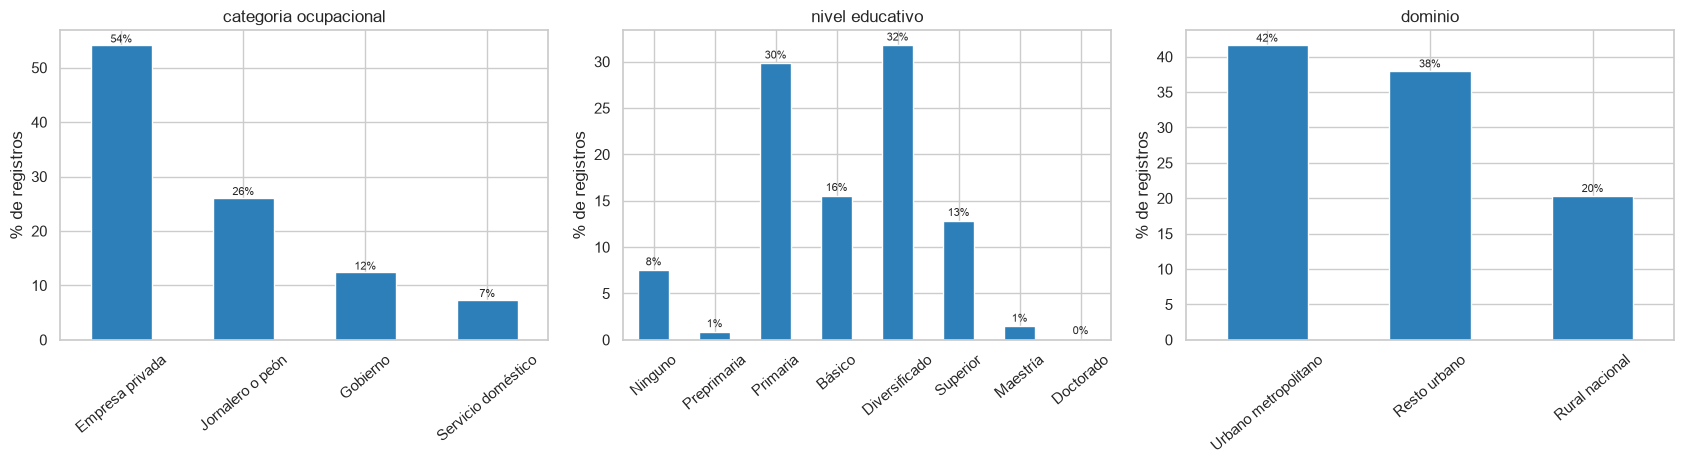

In [13]:
fig, ejes = plt.subplots(1, 3, figsize=(17, 4.8))
ORDEN_NIVEL = list(NIVEL.values()) + ["DESCONOCIDO"]
for eje, col, orden in [(ejes[0], "categoria_ocupacional", None),
                        (ejes[1], "nivel_educativo", ORDEN_NIVEL),
                        (ejes[2], "dominio", None)]:
    t = eneic_2025.groupBy(col).count().toPandas().set_index(col)["count"]
    t = t.reindex([o for o in orden if o in t.index]) if orden else t.sort_values(ascending=False)
    (100 * t / t.sum()).plot.bar(ax=eje, color="#2c7fb8")
    eje.set_title(col.replace("_", " "))
    eje.set_ylabel("% de registros")
    eje.set_xlabel("")
    eje.tick_params(axis="x", rotation=40)
    for i, v in enumerate(100 * t / t.sum()):
        eje.text(i, v + 0.5, f"{v:.0f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

Más de la mitad de los asalariados trabaja en una empresa privada, seguidos por los
jornaleros o peones y los empleados de gobierno, mientras que el servicio doméstico es el grupo
más pequeño. Por nivel educativo dominan la primaria y el diversificado, y muy pocos registros
llegan a maestría o doctorado, lo que hará que las estimaciones de esos grupos sean inestables.
Por dominio, el urbano metropolitano concentra el 42 por ciento de los asalariados, el
resto urbano el 38 y el rural nacional solo el 20, lo que es coherente con que el empleo
asalariado es más frecuente en las ciudades.

### ¿El salario presenta una distribución simétrica o asimétrica? ¿Qué diferencia existe
entre su media y su mediana?

Graficamos una muestra de 5 000 registros en escala lineal y en escala logarítmica. La
escala logarítmica es solo para visualizar, el objetivo del modelado se mantiene en quetzales.

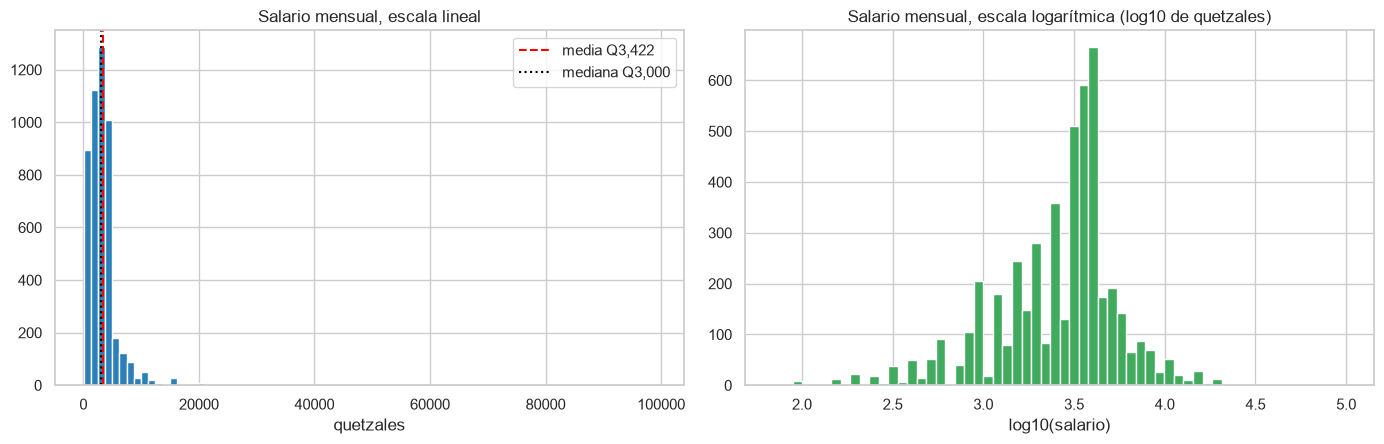

asimetría: 6.00 | media - mediana: Q422


In [14]:
muestra = (eneic_2025.sample(fraction=min(1.0, 5000 / eneic_2025.count()), seed=SEMILLA)
           .select("salario_mensual").toPandas()["salario_mensual"])
media = descriptivas.loc["Salario mensual (Q)", "media"]
mediana = descriptivas.loc["Salario mensual (Q)", "mediana"]
asim = eneic_2025.select(F.skewness("salario_mensual")).first()[0]

fig, ejes = plt.subplots(1, 2, figsize=(14, 4.6))
ejes[0].hist(muestra, bins=80, color="#2c7fb8")
ejes[0].axvline(media, color="red", ls="--", label=f"media Q{media:,.0f}")
ejes[0].axvline(mediana, color="black", ls=":", label=f"mediana Q{mediana:,.0f}")
ejes[0].set_title("Salario mensual, escala lineal")
ejes[0].set_xlabel("quetzales")
ejes[0].legend()
ejes[1].hist(np.log10(muestra), bins=60, color="#41ab5d")
ejes[1].set_title("Salario mensual, escala logarítmica (log10 de quetzales)")
ejes[1].set_xlabel("log10(salario)")
plt.tight_layout()
plt.show()
print(f"asimetría: {asim:.2f} | media - mediana: Q{media - mediana:,.0f}")

El salario es claramente asimétrico hacia la derecha. La mayoría de los registros se
concentra por debajo de Q5 000 y una cola larga de salarios altos llega hasta Q99 000, con un
coeficiente de asimetría muy por encima de cero. Por esa cola la media queda unos Q400 por
encima de la mediana, así que la mediana describe mejor el salario típico. En escala
logarítmica la distribución se ve casi simétrica, lo que confirma el sesgo multiplicativo. El
valor más alto, Q99 000, corresponde a una misma persona observada en tres trimestres, y
también hay unos pocos salarios de menos de Q100. Los conservamos, como pide el enunciado, y
tendremos en cuenta su influencia al evaluar los modelos.

### ¿Cómo varía el salario mediano entre niveles educativos y categorías
ocupacionales?

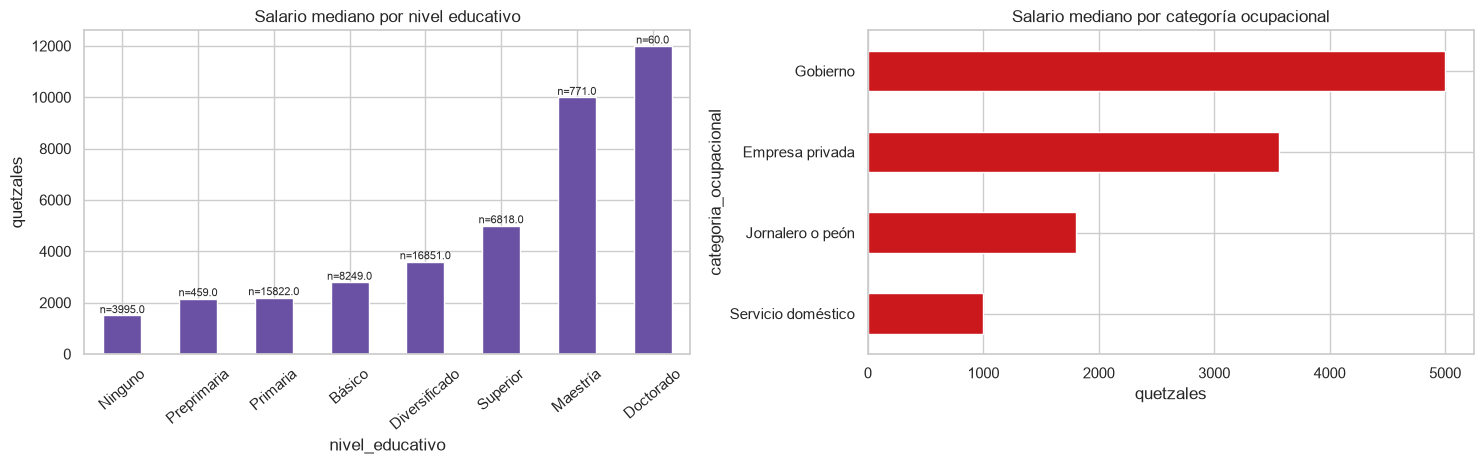

,mediana,n
nivel_educativo,,
Ninguno,1500.0,3995.0
Preprimaria,2160.0,459.0
Primaria,2200.0,15822.0
Básico,2800.0,8249.0
Diversificado,3600.0,16851.0
Superior,5000.0,6818.0
Maestría,10000.0,771.0
Doctorado,12000.0,60.0


,mediana,n
categoria_ocupacional,,
Servicio doméstico,1000.0,3906
Jornalero o peón,1800.0,13842
Empresa privada,3565.0,28702
Gobierno,5000.0,6575


In [15]:
def mediana_por(col):
    return (eneic_2025.groupBy(col)
            .agg(F.percentile_approx("salario_mensual", 0.5, 100000).alias("mediana"),
                 F.count("*").alias("n")).toPandas().set_index(col))

med_nivel = mediana_por("nivel_educativo").reindex([o for o in ORDEN_NIVEL])
med_nivel = med_nivel.dropna()
med_cat = mediana_por("categoria_ocupacional").sort_values("mediana")

fig, ejes = plt.subplots(1, 2, figsize=(15, 4.8))
med_nivel["mediana"].plot.bar(ax=ejes[0], color="#6a51a3")
ejes[0].set_title("Salario mediano por nivel educativo")
ejes[0].set_ylabel("quetzales")
ejes[0].tick_params(axis="x", rotation=40)
for i, (m, n) in enumerate(zip(med_nivel["mediana"], med_nivel["n"])):
    ejes[0].text(i, m, f"n={n}", ha="center", va="bottom", fontsize=8)
med_cat["mediana"].plot.barh(ax=ejes[1], color="#cb181d")
ejes[1].set_title("Salario mediano por categoría ocupacional")
ejes[1].set_xlabel("quetzales")
plt.tight_layout()
plt.show()
display(med_nivel, med_cat)

El salario mediano crece con el nivel educativo de forma casi escalonada. Quienes no
tienen escolaridad tienen una mediana de Q1 500 y quienes tienen primaria de Q2 200, frente a
Q3 600 del diversificado, y los niveles superior, con Q5 000, y de posgrado se separan con
claridad. Maestría y
doctorado tienen muy pocos registros, así que su mediana debe leerse con cautela. Entre
categorías, los empleados de gobierno tienen el salario mediano más alto, Q5 000, seguidos de
la empresa privada con unos Q3 600, mientras que los jornaleros, con Q1 800, y el servicio
doméstico, con Q1 000, quedan muy por debajo. Son
asociaciones descriptivas, no efectos causales de la educación o del sector.

### ¿Cómo cambian el tamaño de la muestra analítica y el salario mediano entre
trimestres?

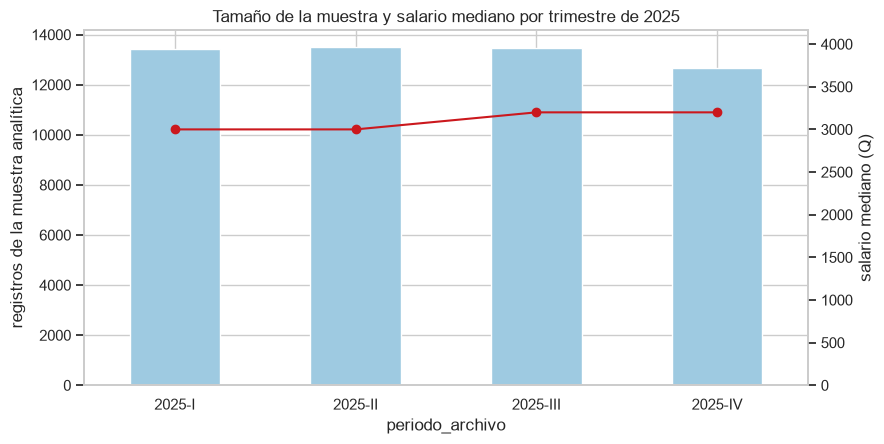

,registros,mediana,media
periodo_archivo,,,
2025-I,13419,3000.0,3315.6
2025-II,13492,3000.0,3364.6
2025-III,13450,3200.0,3469.1
2025-IV,12664,3200.0,3544.6


In [16]:
por_periodo = (eneic_2025.groupBy("periodo_archivo")
               .agg(F.count("*").alias("registros"),
                    F.percentile_approx("salario_mensual", 0.5, 100000).alias("mediana"),
                    F.mean("salario_mensual").alias("media"))
               .orderBy("periodo_archivo").toPandas().set_index("periodo_archivo"))

fig, eje1 = plt.subplots(figsize=(9, 4.6))
por_periodo["registros"].plot.bar(ax=eje1, color="#9ecae1", label="registros")
eje1.set_ylabel("registros de la muestra analítica")
eje1.tick_params(axis="x", rotation=0)
eje2 = eje1.twinx()
eje2.plot(range(len(por_periodo)), por_periodo["mediana"], "-o", color="#cb181d",
          label="salario mediano")
eje2.set_ylabel("salario mediano (Q)")
eje2.set_ylim(0, por_periodo["mediana"].max() * 1.3)
eje2.grid(False)
eje1.set_title("Tamaño de la muestra y salario mediano por trimestre de 2025")
plt.tight_layout()
plt.show()
por_periodo.round(1)

La muestra analítica es estable entre trimestres, con alrededor de 13 400 registros en
los tres primeros y una caída a unos 12 700 en el cuarto, que coincide con que ese archivo
tiene menos registros originales. El salario mediano sube de Q3 000 en los dos primeros
trimestres a Q3 200 en el tercero y el cuarto, y la media sigue la misma tendencia. Es un cambio
moderado que puede reflejar ajustes salariales en el año o diferencias en la composición de la
muestra, y no afecta la decisión de usar los cuatro trimestres en conjunto para desarrollar los
modelos.

## Ejercicio 3. Matriz de correlación

Medimos la relación lineal entre las cuatro variables numéricas de la población analítica de
2025, salario mensual, edad, antigüedad y horas habituales. Spark no calcula correlaciones
sobre columnas sueltas, así que primero las juntamos en un solo vector con VectorAssembler y
luego usamos Correlation.corr de pyspark.ml.stat. Calculamos Pearson, que mide asociación
lineal, y Spearman, que trabaja sobre los rangos y es menos sensible a la cola larga del
salario que vimos en el ejercicio 2.

In [17]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

NUM_CORR = list(VARS)
ETIQ_CORR = [VARS[c] for c in NUM_CORR]
vec_num = (VectorAssembler(inputCols=NUM_CORR, outputCol="vars_num")
           .transform(eneic_2025).select("vars_num"))

corr = {}
for metodo in ["pearson", "spearman"]:
    matriz = Correlation.corr(vec_num, "vars_num", metodo).first()[0].toArray()
    corr[metodo] = pd.DataFrame(matriz, index=ETIQ_CORR, columns=ETIQ_CORR)

for metodo, tabla in corr.items():
    print(metodo)
    display(tabla.round(3))

pearson


,Salario mensual (Q),Edad,Antigüedad (años),Horas habituales
Salario mensual (Q),1.000,0.147,0.180,0.076
Edad,0.147,1.000,0.487,-0.105
Antigüedad (años),0.180,0.487,1.000,-0.062
Horas habituales,0.076,-0.105,-0.062,1.000


spearman


,Salario mensual (Q),Edad,Antigüedad (años),Horas habituales
Salario mensual (Q),1.000,0.153,0.261,0.143
Edad,0.153,1.000,0.419,-0.120
Antigüedad (años),0.261,0.419,1.000,-0.048
Horas habituales,0.143,-0.120,-0.048,1.000


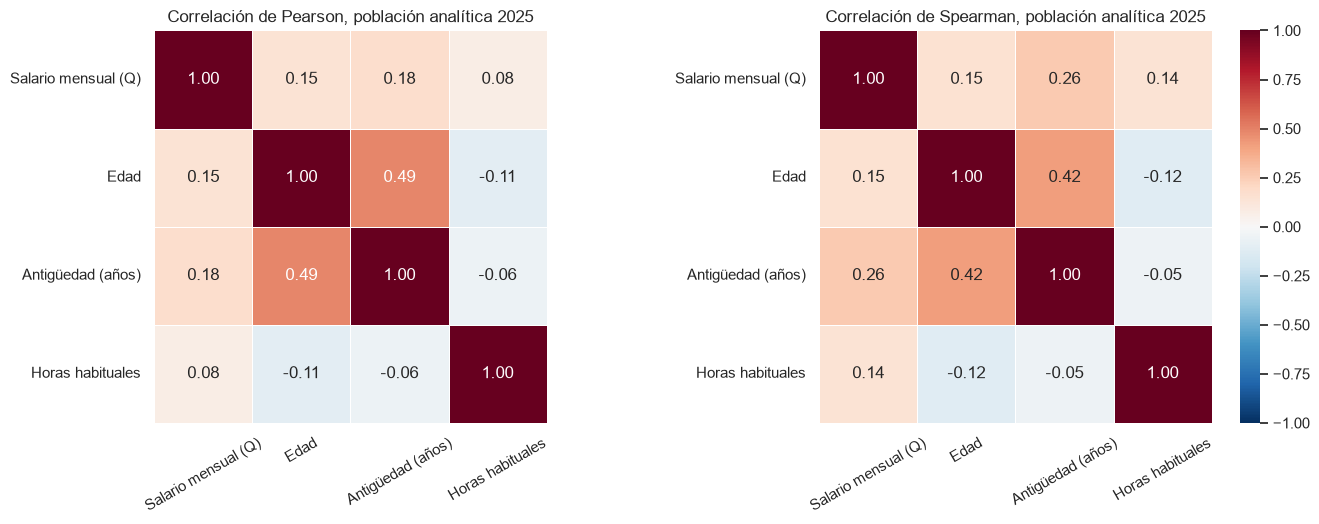

In [18]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5.4))
for eje, (metodo, tabla) in zip(ejes, corr.items()):
    sns.heatmap(tabla, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True,
                linewidths=0.5, cbar=eje is ejes[1], ax=eje)
    eje.set_title(f"Correlación de {metodo.capitalize()}, población analítica 2025")
    eje.tick_params(axis="x", rotation=30)
    eje.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

Todas las correlaciones con el salario son débiles. Con Pearson la más alta es la de la
antigüedad, 0.18, seguida de la edad con 0.15, y las horas casi no se relacionan con el salario,
0.08. Con Spearman la relación con la antigüedad sube a 0.26 y la de las horas a 0.14, porque al
usar rangos se reduce el peso de los pocos salarios muy altos. La relación entre salario y
estas variables existe y es positiva, pero no es lineal ni fuerte, así que por sí solas explican
poco de la variación del salario. En el ejercicio 2 vimos que el nivel educativo y la categoría
ocupacional separan mucho más los salarios, y esas variables no entran en esta matriz porque
son categóricas.

La correlación más alta de la matriz es entre edad y antigüedad, 0.49 con Pearson. Es una
relación en parte estructural, nadie puede llevar más años en un empleo que años de vida, y
por eso uno de nuestros filtros exigía que la antigüedad no superara la edad. No es tan alta
como para que las dos variables sean redundantes, pero conviene tenerla en cuenta al
interpretar sus efectos por separado en un modelo lineal. Las horas tienen correlaciones
negativas y muy pequeñas con la edad y la antigüedad, los trabajadores más jóvenes reportan
jornadas algo más largas. Estas asociaciones son descriptivas y no ponderadas, no indican que
trabajar más años cause un salario mayor.

### Respuestas del ejercicio 3

**¿Qué variables presentan mayor asociación lineal con el salario?** La antigüedad, con una
correlación de Pearson de 0.18, seguida de la edad con 0.15. Las horas habituales tienen la
asociación más débil, 0.08. Las tres son positivas pero débiles, ninguna explica por sí sola más
del 4 por ciento de la varianza del salario (el cuadrado de 0.18 es 0.03). Parte de esa debilidad
se debe a la cola larga del salario, con Spearman las asociaciones con la antigüedad y las horas
suben a 0.26 y 0.14.

**¿Existe relación entre edad y antigüedad?** Sí, es la asociación más fuerte de la matriz, 0.49
con Pearson y 0.42 con Spearman, positiva y moderada. Las personas mayores tienden a llevar más
tiempo en su empleo, y la antigüedad está acotada por la edad. No es una relación perfecta porque
muchas personas mayores cambiaron de trabajo hace poco y tienen poca antigüedad.

## Ejercicio 4. Segmentación de perfiles con KMeans

### Preparación de variables

Buscamos grupos de asalariados con características parecidas. KMeans trabaja con distancias
euclidianas, así que todas las variables tienen que ser numéricas y estar en escalas comparables,
de lo contrario la edad, medida en decenas, pesaría mucho más que el nivel educativo. Usamos cinco
variables:

- el logaritmo del salario mensual, porque en quetzales la cola larga haría que unos pocos
  salarios altos dominaran las distancias y formaran grupos por sí solos,
- la edad, la antigüedad y las horas habituales,
- el nivel educativo como variable ordinal de 0 (ninguno) a 7 (doctorado), ya que sus
  categorías tienen un orden natural.

Juntamos las cinco con VectorAssembler y las estandarizamos con StandardScaler, centrando en la
media y dividiendo entre la desviación estándar. El escalador se ajusta solo con 2025 y después
se reutiliza sin cambios para 2026. La categoría ocupacional y el dominio no entran al modelo,
las usamos después para describir los grupos.

In [19]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

NIVEL_ORD = {etiqueta: float(k) for k, etiqueta in NIVEL.items()}
VARS_KM = ["log_salario", "edad", "antiguedad", "horas_semanales", "nivel_ord"]


def preparar_km(sdf):
    nivel = F.lit(None).cast("double")
    for etiqueta, k in NIVEL_ORD.items():
        nivel = F.when(F.col("nivel_educativo") == etiqueta, k).otherwise(nivel)
    return (sdf.withColumn("nivel_ord", nivel)
               .withColumn("log_salario", F.log("salario_mensual")))


km_2025 = preparar_km(eneic_2025)
# un nivel DESCONOCIDO no tendría código ordinal y VectorAssembler fallaría
print("registros sin nivel ordinal:", km_2025.filter(F.col("nivel_ord").isNull()).count())

escalado = Pipeline(stages=[
    VectorAssembler(inputCols=VARS_KM, outputCol="vars_km"),
    StandardScaler(inputCol="vars_km", outputCol="features", withMean=True, withStd=True),
]).fit(km_2025)
X_2025 = escalado.transform(km_2025).cache()

escalador = escalado.stages[-1]
display(pd.DataFrame({"media": escalador.mean.toArray(), "desv_est": escalador.std.toArray()},
                     index=VARS_KM).round(3))
X_2025.select(VARS_KM + ["features"]).show(5, truncate=False)

registros sin nivel ordinal: 0


,media,desv_est
log_salario,7.867,0.794
edad,35.188,13.521
antiguedad,5.559,7.831
horas_semanales,46.307,18.630
nivel_ord,3.081,1.409


+-----------------+----+------------------+---------------+---------+-----------------------------------------------------------------------------------------------------+
|log_salario      |edad|antiguedad        |horas_semanales|nivel_ord|features                                                                                             |
+-----------------+----+------------------+---------------+---------+-----------------------------------------------------------------------------------------------------+
|8.160518247477505|35.0|2.4166666666666665|25.0           |5.0      |[0.37034582704158375,-0.013878315338334547,-0.4012455672939364,-1.143689579500175,1.3615859367820164]|
|9.148464968258095|56.0|34.0              |27.0           |4.0      |[1.6153947603129053,1.5392725476885925,3.631861832726877,-1.0363381933067437,0.6519177370683837]     |
|7.600902459542082|23.0|3.0               |73.0           |5.0      |[-0.33490378324132436,-0.9013930942108643,-0.3267554570033145,1.4327436

### Por qué dejamos fuera las variables categóricas

Una primera versión agregaba la categoría ocupacional y el dominio en one-hot. Después de
estandarizar, cada indicador de una categoría poco frecuente, como servicio doméstico, toma
valores muy grandes para las pocas personas que la tienen, y esas columnas terminan decidiendo
las distancias. La celda siguiente repite esa versión para mostrar el efecto.

In [20]:
variante_oh = Pipeline(stages=[
    StringIndexer(inputCols=["categoria_ocupacional", "dominio"], outputCols=["cat_i", "dom_i"]),
    OneHotEncoder(inputCols=["cat_i", "dom_i"], outputCols=["cat_oh", "dom_oh"], dropLast=False),
    VectorAssembler(inputCols=VARS_KM + ["cat_oh", "dom_oh"], outputCol="vars_oh"),
    StandardScaler(inputCol="vars_oh", outputCol="features", withMean=True, withStd=True),
]).fit(km_2025)
X_oh = variante_oh.transform(km_2025)
pred_oh = KMeans(k=5, seed=SEMILLA, maxIter=50).fit(X_oh).transform(X_oh)
(pred_oh.groupBy("prediction").pivot("categoria_ocupacional").count()
 .fillna(0).orderBy("prediction").show())

+----------+---------------+--------+----------------+------------------+
|prediction|Empresa privada|Gobierno|Jornalero o peón|Servicio doméstico|
+----------+---------------+--------+----------------+------------------+
|         0|              0|    6575|               0|                 0|
|         1|          15838|       0|              17|                 0|
|         2|              0|       0|               0|              3906|
|         3|             19|       0|           13825|                 0|
|         4|          12845|       0|               0|                 0|
+----------+---------------+--------+----------------+------------------+



Cada grupo coincide casi exactamente con una categoría ocupacional, gobierno, servicio
doméstico y jornaleros quedan cada uno en su propio grupo y la empresa privada se parte en dos.
El modelo no descubre perfiles, solo reproduce una variable que ya conocíamos. Por eso
agrupamos con las cinco variables numéricas y dejamos la categoría y el dominio para
interpretar los grupos que salgan.

### Selección de k

Probamos k de 2 a 10 con tres semillas distintas para cada valor. Para cada modelo registramos la
suma de distancias cuadradas de cada punto a su centro (WSSSE), que siempre baja al agregar
grupos y se usa para buscar el codo, y el coeficiente de silueta de ClusteringEvaluator, que
compara qué tan cerca está cada punto de su grupo frente al grupo vecino y va de -1 a 1.

In [21]:
evaluador = ClusteringEvaluator(featuresCol="features", predictionCol="prediction",
                                metricName="silhouette", distanceMeasure="squaredEuclidean")
SEMILLAS = [SEMILLA, 23645, 7]
filas = []
for k in range(2, 11):
    for s in SEMILLAS:
        modelo = KMeans(k=k, seed=s, maxIter=50).fit(X_2025)
        filas.append({"k": k, "semilla": s, "wssse": modelo.summary.trainingCost,
                      "silueta": evaluador.evaluate(modelo.transform(X_2025)),
                      "grupo_menor": min(modelo.summary.clusterSizes)})
pruebas_k = pd.DataFrame(filas)
seleccion_k = pruebas_k.groupby("k").agg(
    wssse=("wssse", "min"), silueta=("silueta", "mean"),
    silueta_min=("silueta", "min"), silueta_max=("silueta", "max"),
    grupo_menor=("grupo_menor", "min"))
seleccion_k.round(3)

,wssse,silueta,silueta_min,silueta_max,grupo_menor
k,,,,,
2,211548.487,0.386,0.367,0.415,15782
3,170454.769,0.395,0.395,0.395,8904
4,147370.523,0.332,0.328,0.340,7125
5,130426.532,0.334,0.317,0.342,3692
6,117796.990,0.341,0.337,0.350,3419
7,106760.295,0.350,0.349,0.350,2562
8,100811.105,0.317,0.299,0.351,2256
9,95211.220,0.309,0.309,0.309,2186
10,91766.662,0.296,0.281,0.305,1214


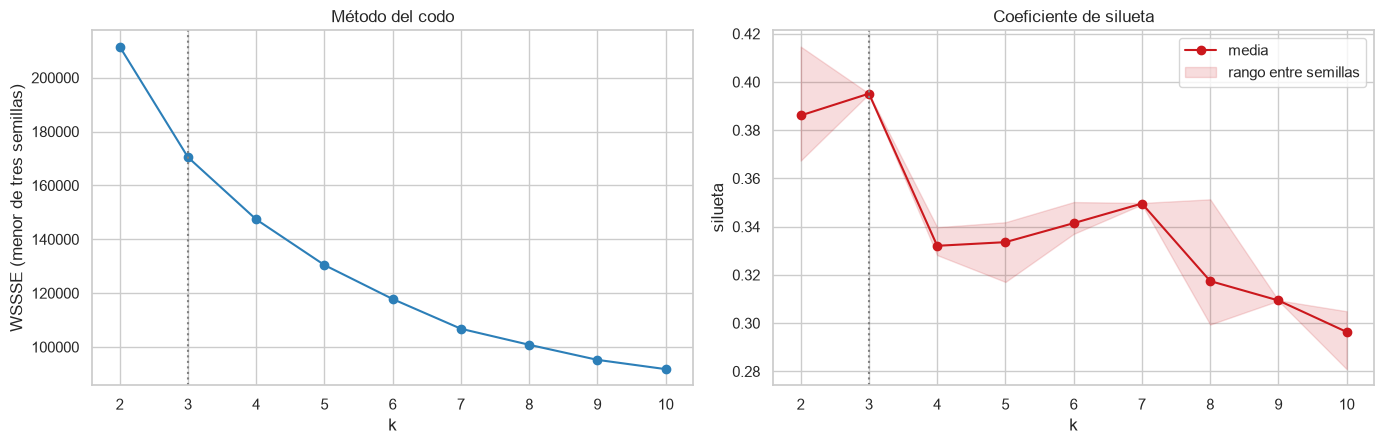

In [22]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4.6))
ejes[0].plot(seleccion_k.index, seleccion_k["wssse"], "-o", color="#2c7fb8")
ejes[0].set_title("Método del codo")
ejes[0].set_xlabel("k")
ejes[0].set_ylabel("WSSSE (menor de tres semillas)")
ejes[1].plot(seleccion_k.index, seleccion_k["silueta"], "-o", color="#cb181d", label="media")
ejes[1].fill_between(seleccion_k.index, seleccion_k["silueta_min"], seleccion_k["silueta_max"],
                     color="#cb181d", alpha=0.15, label="rango entre semillas")
ejes[1].set_title("Coeficiente de silueta")
ejes[1].set_xlabel("k")
ejes[1].set_ylabel("silueta")
ejes[1].legend()
for eje in ejes:
    eje.axvline(3, color="gray", ls=":")
plt.tight_layout()
plt.show()

El WSSSE baja de forma suave y no muestra un codo marcado, la caída más grande es de k = 2 a
k = 3 y desde ahí cada grupo adicional reduce cada vez menos. La silueta es más clara, alcanza su
máximo en k = 3 con 0.395 y ese valor es el mismo con las tres semillas, es decir, la solución
es estable. Con k = 4 la silueta cae a 0.33 y desde k = 8 sigue bajando y aparecen grupos
pequeños que dependen de la semilla. Elegimos k = 3. Una silueta cercana a 0.4 indica grupos
razonablemente separados pero no muy compactos, algo esperable en datos de personas donde los
perfiles se traslapan.

### ¿Vale la pena incluir el salario?

El enunciado pide analizar si el salario debe entrar al clustering. Comparamos dos versiones con
el mismo escalado, una con las cuatro variables sin salario y otra con el logaritmo del salario,
para k de 2 a 5 y las mismas tres semillas. Las siluetas de las dos versiones no se pueden
comparar directamente, porque se calculan en espacios con distinto número de dimensiones, así que
miramos además dos cosas, si la solución cambia con la semilla y qué parte de la varianza del
logaritmo del salario queda explicada por los grupos, es decir, qué tanto separan los grupos a
personas con salarios distintos.

In [23]:
VARIANTES_KM = {"sin salario": [c for c in VARS_KM if c != "log_salario"], "con salario": VARS_KM}
var_log_sal = km_2025.select(F.variance("log_salario")).first()[0]


def varianza_salario_explicada(pred):
    # 1 - varianza promedio del log del salario dentro de los grupos / varianza total
    dentro = (pred.groupBy("prediction")
              .agg(F.count("*").alias("n"), F.variance("log_salario").alias("v"))
              .select(F.sum(F.col("n") * F.col("v")) / F.sum("n")).first()[0])
    return 1 - dentro / var_log_sal


filas, perfiles_variante = [], {}
for variante, cols in VARIANTES_KM.items():
    X_var = Pipeline(stages=[
        VectorAssembler(inputCols=cols, outputCol="vars_var"),
        StandardScaler(inputCol="vars_var", outputCol="features", withMean=True, withStd=True),
    ]).fit(km_2025).transform(km_2025).cache()
    for k in range(2, 6):
        siluetas = []
        for s in SEMILLAS:
            pred = KMeans(k=k, seed=s, maxIter=50).fit(X_var).transform(X_var)
            siluetas.append(evaluador.evaluate(pred))
            if s == SEMILLA:
                explicada = varianza_salario_explicada(pred)
                if k == 3:
                    perfiles_variante[variante] = (pred.groupBy("prediction").agg(
                        F.count("*").alias("registros"),
                        F.percentile_approx("salario_mensual", [0.25, 0.5, 0.75], 100000).alias("p"),
                        *[F.mean(c).alias(c) for c in ["edad", "antiguedad", "horas_semanales", "nivel_ord"]])
                        .toPandas())
        filas.append({"variante": variante, "k": k, "silueta_media": np.mean(siluetas),
                      "silueta_min": min(siluetas), "silueta_max": max(siluetas),
                      "varianza_log_salario_explicada": explicada})
    X_var.unpersist()

comparacion_salario = pd.DataFrame(filas).set_index(["variante", "k"])
display(comparacion_salario.round(3))
for variante, t in perfiles_variante.items():
    t[["p25", "salario_mediano", "p75"]] = pd.DataFrame(t.pop("p").tolist(), index=t.index)
    print(f"k = 3, {variante}:")
    display(t.sort_values("salario_mediano").set_index("prediction").round(1))

silueta_media  silueta_min  silueta_max  \
variante    k                                            
sin salario 2          0.467        0.467        0.467   
            3          0.387        0.369        0.424   
            4          0.372        0.372        0.372   
            5          0.366        0.364        0.368   
con salario 2          0.386        0.367        0.415   
            3          0.395        0.395        0.395   
            4          0.332        0.328        0.340   
            5          0.334        0.317        0.342   

               varianza_log_salario_explicada  
variante    k                                  
sin salario 2                           0.000  
            3                           0.101  
            4                           0.102  
            5                           0.162  
con salario 2                           0.356  
            3                           0.419  
            4                           0.497  
            5                           0.506

k = 3, sin salario:


,registros,edad,antiguedad,horas_semanales,nivel_ord,p25,salario_mediano,p75
prediction,,,,,,,,
2,13017,44.8,3.6,41.6,1.6,1100.0,2000.0,3200.0
0,32118,27.6,2.7,49.1,3.6,2000.0,3300.0,4000.0
1,7890,50.2,20.5,42.5,3.4,2800.0,3973.0,6000.0


k = 3, con salario:


,registros,edad,antiguedad,horas_semanales,nivel_ord,p25,salario_mediano,p75
prediction,,,,,,,,
0,13858,37.5,3.1,35.0,1.8,700.0,1200.0,2000.0
1,30252,29.6,2.8,52.3,3.6,2600.0,3500.0,4000.0
2,8915,50.6,18.8,43.6,3.4,3000.0,4000.0,6000.0


Sin salario, la mejor silueta es la de k = 2, 0.467, pero esos dos grupos no separan salarios en
absoluto, explican el 0 por ciento de la varianza del logaritmo del salario. Con k = 3 la silueta
cambia bastante con la semilla, en nuestras ejecuciones entre 0.35 y 0.42, así que la solución no es
estable, y los grupos explican como mucho el 10 por ciento de la varianza salarial. Incluso con
k = 5 no pasan del 16 por ciento. Los grupos se forman sobre todo por edad, antigüedad y horas, y
dentro de cada uno conviven salarios muy distintos, ninguno tiene un salario mediano por debajo de
Q2 000 y los rangos entre el percentil 25 y el 75 de los tres grupos se traslapan.

Con salario, k = 3 da la misma silueta con las tres semillas, 0.395, la más alta de esta variante, y
los grupos explican el 42 por ciento de la varianza del logaritmo del salario. Además aparece un
perfil que la versión sin salario no identifica, el de ingresos bajos y jornada corta, con salario
mediano de Q1 200 y tres cuartas partes por debajo de Q2 000. Sin salario, esas personas quedan
mezcladas con personas que ganan bastante más.

Por eso decidimos incluir el salario. La pregunta del laboratorio es qué perfiles de asalariados
existen, y el ingreso es parte central de un perfil laboral. Lo incluimos en logaritmo para que la
cola de salarios altos no domine las distancias. Esta decisión solo afecta a la segmentación. Los
grupos no se usan como predictores en los ejercicios 5 a 8, así que no hay fuga del objetivo hacia
los modelos de regresión.

### Modelo final y perfiles

Ajustamos KMeans con k = 3 sobre 2025 y describimos cada grupo en las unidades originales. Los
números de cluster que asigna Spark son arbitrarios, así que les ponemos nombre según sus
características, el grupo con mayor antigüedad media, el de menor salario mediano y el restante.

In [24]:
K = 3
kmeans = KMeans(k=K, seed=SEMILLA, maxIter=50).fit(X_2025)
seg_2025 = kmeans.transform(X_2025).cache()
print("silueta:", round(evaluador.evaluate(seg_2025), 3))


def perfil_grupos(sdf):
    return (sdf.groupBy("prediction").agg(
        F.count("*").alias("registros"),
        F.percentile_approx("salario_mensual", 0.5, 100000).alias("salario_mediano"),
        F.mean("edad").alias("edad_media"),
        F.percentile_approx("antiguedad", 0.5, 100000).alias("antiguedad_mediana"),
        F.mean("antiguedad").alias("antiguedad_media"),
        F.percentile_approx("horas_semanales", 0.5, 100000).alias("horas_medianas"),
        F.mean("horas_semanales").alias("horas_medias"),
        F.mean("nivel_ord").alias("nivel_ord_medio"),
        *[F.mean((F.col("categoria_ocupacional") == v).cast("int")).alias(v)
          for v in CATEGORIA.values()],
        *[F.mean((F.col("dominio") == v).cast("int")).alias(v) for v in DOMINIO.values()])
        .toPandas().set_index("prediction").sort_index())


perfiles = perfil_grupos(seg_2025)
id_veteranos = perfiles["antiguedad_media"].idxmax()
id_bajos = perfiles.drop(id_veteranos)["salario_mediano"].idxmin()
id_jovenes = next(i for i in perfiles.index if i not in (id_veteranos, id_bajos))
NOMBRES = {id_bajos: "Ingresos bajos y jornada corta",
           id_jovenes: "Jóvenes de jornada larga",
           id_veteranos: "Veteranos con alta antigüedad"}
ORDEN_PERFIL = [NOMBRES[i] for i in (id_bajos, id_jovenes, id_veteranos)]

perfiles = perfiles.rename(index=NOMBRES).reindex(ORDEN_PERFIL)
perfiles.insert(1, "porcentaje", 100 * perfiles["registros"] / perfiles["registros"].sum())
perfiles.T.round(2)

silueta: 0.395


prediction,Ingresos bajos y jornada corta,Jóvenes de jornada larga,Veteranos con alta antigüedad
registros,13858.00,30252.00,8915.00
porcentaje,26.13,57.05,16.81
salario_mediano,1200.00,3500.00,4000.00
edad_media,37.47,29.59,50.64
antiguedad_mediana,1.00,2.00,17.00
antiguedad_media,3.13,2.76,18.84
horas_medianas,38.00,48.00,42.00
horas_medias,35.01,52.28,43.61
nivel_ord_medio,1.79,3.59,3.38
Gobierno,0.02,0.11,0.33


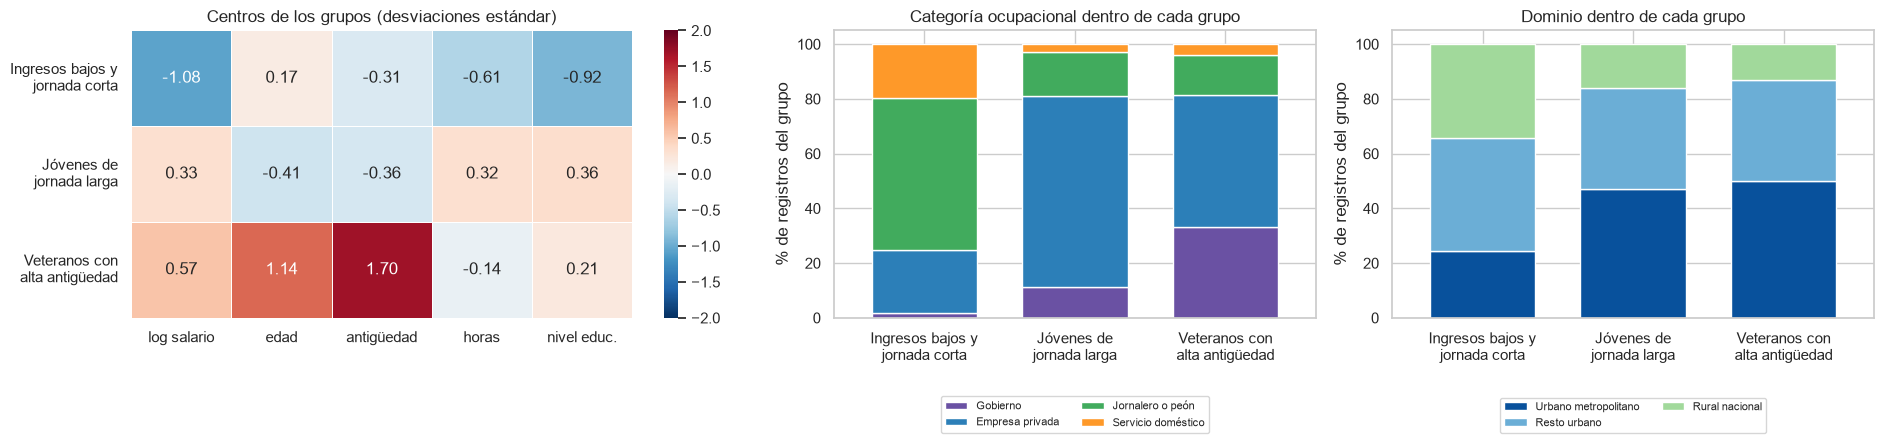

In [25]:
centros = pd.DataFrame(kmeans.clusterCenters(), columns=VARS_KM).rename(index=NOMBRES)
centros = centros.reindex(ORDEN_PERFIL)
etiq_perfil = [p.replace(" y ", " y\n").replace(" de ", " de\n").replace(" con ", " con\n")
               for p in ORDEN_PERFIL]

fig, ejes = plt.subplots(1, 3, figsize=(19, 5), gridspec_kw={"width_ratios": [1.3, 1, 1]})
sns.heatmap(centros.set_axis(etiq_perfil), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-2, vmax=2, linewidths=0.5, ax=ejes[0],
            xticklabels=["log salario", "edad", "antigüedad", "horas", "nivel educ."])
ejes[0].set_title("Centros de los grupos (desviaciones estándar)")
ejes[0].tick_params(axis="y", rotation=0)

colores_cat = ["#6a51a3", "#2c7fb8", "#41ab5d", "#fe9929"]
(100 * perfiles[list(CATEGORIA.values())]).set_axis(etiq_perfil).plot.bar(
    stacked=True, ax=ejes[1], color=colores_cat, width=0.7)
ejes[1].set_title("Categoría ocupacional dentro de cada grupo")
colores_dom = ["#08519c", "#6baed6", "#a1d99b"]
(100 * perfiles[list(DOMINIO.values())]).set_axis(etiq_perfil).plot.bar(
    stacked=True, ax=ejes[2], color=colores_dom, width=0.7)
ejes[2].set_title("Dominio dentro de cada grupo")
for eje in ejes[1:]:
    eje.set_ylabel("% de registros del grupo")
    eje.tick_params(axis="x", rotation=0)
    eje.legend(fontsize=8, loc="lower center", bbox_to_anchor=(0.5, -0.42), ncol=2)
plt.tight_layout()
plt.show()

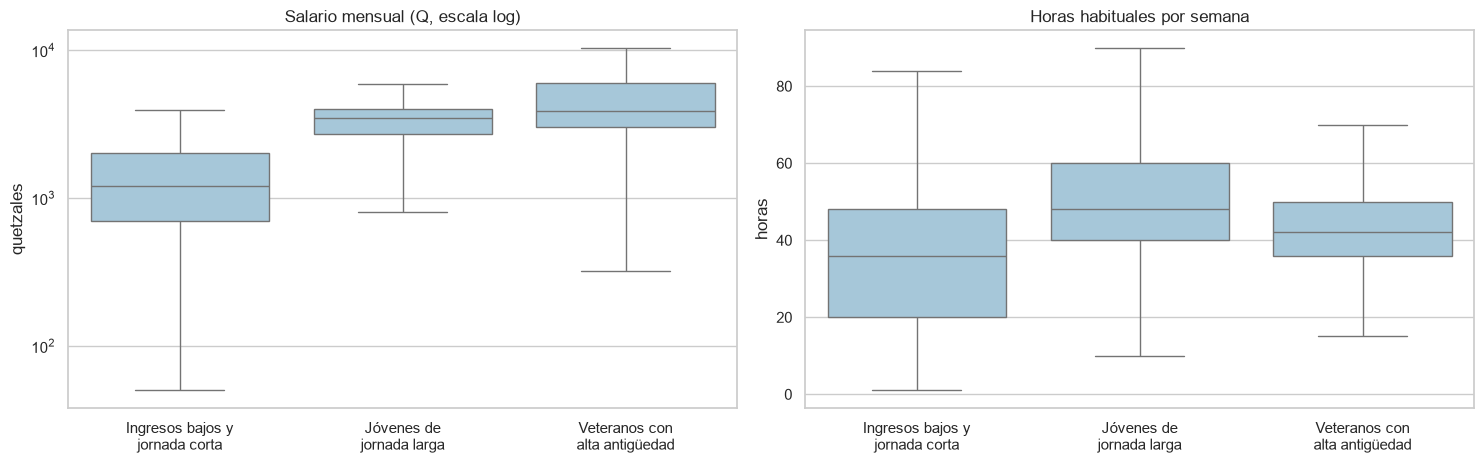

In [26]:
muestra_seg = (seg_2025.sample(fraction=min(1.0, 8000 / seg_2025.count()), seed=SEMILLA)
               .select("prediction", "salario_mensual", "horas_semanales").toPandas())
muestra_seg["perfil"] = muestra_seg["prediction"].map(NOMBRES)

fig, ejes = plt.subplots(1, 2, figsize=(15, 4.8))
for eje, col, titulo in [(ejes[0], "salario_mensual", "Salario mensual (Q, escala log)"),
                         (ejes[1], "horas_semanales", "Horas habituales por semana")]:
    sns.boxplot(data=muestra_seg, x="perfil", y=col, order=ORDEN_PERFIL, ax=eje,
                color="#9ecae1", showfliers=False)
    eje.set_title(titulo)
    eje.set_xlabel("")
    eje.set_xticks(range(len(etiq_perfil)), etiq_perfil)
ejes[0].set_yscale("log")
ejes[0].set_ylabel("quetzales")
ejes[1].set_ylabel("horas")
plt.tight_layout()
plt.show()

Los tres grupos se distinguen sobre todo por salario, antigüedad y nivel educativo.

**Ingresos bajos y jornada corta (26 por ciento).** Salario mediano de Q1 200, menos de la mitad
del de los otros dos grupos, con jornadas más cortas, mediana de 38 horas y una cuarta parte por
debajo de 20, y el nivel educativo más bajo, en promedio entre primaria y básico. Más de la mitad
son jornaleros o peones y una quinta parte trabaja en servicio doméstico, y es el grupo con más
presencia rural, un tercio. Es el perfil del trabajo asalariado precario, parcial o por
temporadas.

**Jóvenes de jornada larga (57 por ciento).** Es el grupo más grande. Tiene una edad media de 30
años y poca antigüedad, mediana de 2 años, pero salario mediano de Q3 500 y el nivel educativo
más alto de los tres, cerca del diversificado. Trabaja las jornadas más largas, con mediana de 48
horas y la mitad central entre 40 y 60. Siete de cada diez están en la empresa privada y casi la
mitad vive en el área metropolitana.

**Veteranos con alta antigüedad (17 por ciento).** Edad media de 51 años y antigüedad mediana de
17 años en el mismo empleo, muy por encima de los otros grupos. Tienen el salario mediano más
alto, Q4 000, con jornadas cercanas a las 42 horas. Un tercio trabaja para el gobierno, la
proporción más alta de los tres grupos, lo que es coherente con la estabilidad del empleo
público, y la mitad está en el área metropolitana.

### Aplicación a 2026 y comparación con k = 4

Para ver si los perfiles se sostienen fuera de los datos con que se construyeron, asignamos los
registros del primer trimestre de 2026 con el mismo escalador y el mismo modelo, sin volver a
ajustar nada. También cruzamos la solución de k = 3 con la de k = 4 para ver qué grupo se parte
al agregar uno más.

In [27]:
X_2026 = escalado.transform(preparar_km(eneic_2026))
seg_2026 = kmeans.transform(X_2026)
print("silueta 2026 con el modelo de 2025:", round(evaluador.evaluate(seg_2026), 3))

perfiles_2026 = perfil_grupos(seg_2026).rename(index=NOMBRES).reindex(ORDEN_PERFIL)
comparacion = pd.DataFrame({
    "% 2025": 100 * perfiles["registros"] / perfiles["registros"].sum(),
    "% 2026": 100 * perfiles_2026["registros"] / perfiles_2026["registros"].sum(),
    "salario mediano 2025": perfiles["salario_mediano"],
    "salario mediano 2026": perfiles_2026["salario_mediano"],
    "antigüedad media 2025": perfiles["antiguedad_media"],
    "antigüedad media 2026": perfiles_2026["antiguedad_media"],
})
comparacion.round(1)

silueta 2026 con el modelo de 2025: 0.398


,% 2025,% 2026,salario mediano 2025,salario mediano 2026,antigüedad media 2025,antigüedad media 2026
prediction,,,,,,
Ingresos bajos y jornada corta,26.1,25.0,1200.0,1200.0,3.1,2.8
Jóvenes de jornada larga,57.1,57.9,3500.0,3629.0,2.8,2.6
Veteranos con alta antigüedad,16.8,17.2,4000.0,4000.0,18.8,18.8


In [28]:
kmeans_4 = KMeans(k=4, seed=SEMILLA, maxIter=50).fit(X_2025)
# se predice k = 4 sobre las mismas filas ya asignadas con k = 3 para cruzar ambas
ambos = kmeans_4.transform(seg_2025.withColumnRenamed("prediction", "k3"))
cruce = (ambos.groupBy("k3").pivot("prediction").count().fillna(0).toPandas()
         .set_index("k3").rename(index=NOMBRES).reindex(ORDEN_PERFIL))
cruce.columns = [f"grupo {c} de k = 4" for c in cruce.columns]
display(cruce)
perfil_grupos(ambos).drop(columns=list(DOMINIO.values())).round(2)

,grupo 0 de k = 4,grupo 1 de k = 4,grupo 2 de k = 4,grupo 3 de k = 4
k3,,,,
Ingresos bajos y jornada corta,8547,4930,230,151
Jóvenes de jornada larga,14,12056,18182,0
Veteranos con alta antigüedad,29,391,1520,6975


,registros,salario_mediano,edad_media,antiguedad_mediana,antiguedad_media,horas_medianas,horas_medias,nivel_ord_medio,Gobierno,Empresa privada,Jornalero o peón,Servicio doméstico
prediction,,,,,,,,,,,,
0,8590,900.0,38.10,1.00,3.30,25.0,26.19,1.92,0.01,0.17,0.57,0.25
1,17377,2600.0,31.13,1.25,2.72,56.0,60.44,2.32,0.04,0.53,0.37,0.07
2,19932,3800.0,31.45,2.00,3.48,44.0,43.58,4.23,0.18,0.74,0.07,0.02
3,7126,3800.0,52.02,20.00,21.01,42.0,43.73,3.12,0.31,0.46,0.18,0.05


Con el modelo de 2025 aplicado sin cambios a 2026 la silueta es 0.398, prácticamente la misma
que en 2025, y los tres grupos conservan su tamaño, 25, 58 y 17 por ciento, y sus salarios
medianos. Los perfiles no son un accidente de la muestra de 2025, se repiten en un trimestre que
el modelo no vio.

El cruce con k = 4 muestra que el grupo que se parte es el de jóvenes de jornada larga. Unos
18 000 registros forman un grupo con el nivel educativo medio más alto, por encima del
diversificado, y jornadas de 44 horas, y otros 12 000 se unen con unos 4 900 del grupo de ingresos
bajos en un grupo de jornadas muy largas, mediana de 56 horas, menor escolaridad y salario
mediano de Q2 600. Esa distinción tiene
sentido, pero la silueta baja de 0.395 a 0.33, es decir, los cuatro grupos se traslapan más.
Mantenemos k = 3 como segmentación principal y dejamos la separación de k = 4 como matiz del grupo
más grande.

### Limitaciones de la segmentación

Los grupos describen los registros de la muestra, no a la población de asalariados del país,
porque KMeans no usa el FACTOR de expansión. KMeans supone grupos más o menos esféricos y de
tamaño parecido y asigna a cada persona a un solo grupo aunque esté en la frontera, algo que
pasa con muchas personas porque la silueta no es alta. Los perfiles dependen de las cinco
variables elegidas y de su escalado, con otras variables saldrían grupos distintos. Por último,
los perfiles no explican por qué alguien gana más, que los veteranos tengan el salario más alto
no significa que la antigüedad lo cause. Como el salario participa en la formación de los grupos,
no usaremos el grupo como variable explicativa al modelar el salario.

## Ejercicio 5. Pipeline de regresión lineal

### Conjuntos de entrenamiento y validación

Estimamos salario_mensual en quetzales, sin transformar, con exactamente seis predictores:
edad, antigüedad, horas semanales, nivel educativo, categoría ocupacional y dominio. No usamos
identificadores, FACTOR, el salario por hora ni el grupo de KMeans.

Separamos por periodo del archivo y no al azar. Los trimestres I a III de 2025 son el
entrenamiento y el IV de 2025 la validación, que sirve para elegir la configuración de cada
algoritmo. Separar por periodo imita el uso real del modelo, que se ajusta con trimestres
pasados y se aplica a uno nuevo, y evita que la misma persona observada en dos trimestres
aparezca a la vez en entrenamiento y en validación dentro de un mismo corte. El primer trimestre
de 2026 no se toca hasta el ejercicio 7.

In [29]:
TRAIN_P = ["2025-I", "2025-II", "2025-III"]
VALID_P = ["2025-IV"]
OBJETIVO = "salario_mensual"
NUM_PRED = ["edad", "antiguedad", "horas_semanales"]
CAT_PRED = ["nivel_educativo", "categoria_ocupacional", "dominio"]

entrenamiento = eneic_2025.filter(F.col("periodo_archivo").isin(TRAIN_P)).cache()
validacion = eneic_2025.filter(F.col("periodo_archivo").isin(VALID_P)).cache()


def resumen_objetivo(sdf):
    r = sdf.select(F.count(OBJETIVO).alias("registros"), F.mean(OBJETIVO).alias("media"),
                   F.percentile_approx(OBJETIVO, [0.5, 0.95], 100000).alias("p"),
                   F.max(OBJETIVO).alias("max")).first()
    return {"registros": r["registros"], "media": r["media"], "mediana": r["p"][0],
            "p95": r["p"][1], "max": r["max"]}


pd.DataFrame({"entrenamiento (2025 I-III)": resumen_objetivo(entrenamiento),
              "validación (2025 IV)": resumen_objetivo(validacion)}).T.round(1)

,registros,media,mediana,p95,max
entrenamiento (2025 I-III),40361.0,3383.1,3000.0,8000.0,99000.0
validación (2025 IV),12664.0,3544.6,3200.0,8000.0,60000.0


Antes de ajustar comprobamos que cada categoría de validación ya exista en entrenamiento.
Si apareciera una nueva, el StringIndexer ajustado con entrenamiento no sabría codificarla.

In [30]:
for c in CAT_PRED:
    nuevas = (validacion.select(c).distinct()
              .join(entrenamiento.select(c).distinct(), on=c, how="left_anti").count())
    print(f"{c:22s} categorías en entrenamiento: {entrenamiento.select(c).distinct().count()}"
          f" | nuevas en validación: {nuevas}")

nivel_educativo        categorías en entrenamiento: 8 | nuevas en validación: 0
categoria_ocupacional  categorías en entrenamiento: 4 | nuevas en validación: 0
dominio                categorías en entrenamiento: 3 | nuevas en validación: 0


### Métricas y modelo de referencia

Evaluamos con MAE, el error absoluto promedio en quetzales, RMSE, que eleva los errores al
cuadrado y por eso castiga más los salarios muy mal estimados, y R², la proporción de la
varianza del salario de ese conjunto que explica el modelo. Todas se calculan con
RegressionEvaluator sobre el conjunto completo.

El modelo de referencia no usa ningún predictor y predice para todas las personas un mismo valor
calculado solo con entrenamiento. Probamos la media, que es la constante que minimiza el RMSE, y
la mediana, que minimiza el MAE. Un modelo con predictores solo vale la pena si mejora sobre
esta referencia.

In [31]:
from pyspark.ml.evaluation import RegressionEvaluator

METRICAS = ["mae", "rmse", "r2"]


def metricas(pred, col_pred="prediction"):
    ev = RegressionEvaluator(labelCol=OBJETIVO, predictionCol=col_pred)
    return {m: ev.evaluate(pred, {ev.metricName: m}) for m in METRICAS}


media_train = entrenamiento.select(F.mean(OBJETIVO)).first()[0]
mediana_train = entrenamiento.select(F.percentile_approx(OBJETIVO, 0.5, 100000)).first()[0]
REFERENCIAS = {"referencia (media)": media_train, "referencia (mediana)": mediana_train}

filas = []
for nombre, valor in REFERENCIAS.items():
    for conjunto, sdf in [("entrenamiento", entrenamiento), ("validación", validacion)]:
        filas.append({"modelo": nombre, "conjunto": conjunto, "predicción": valor,
                      **metricas(sdf.withColumn("prediction", F.lit(valor)))})
referencia = pd.DataFrame(filas).set_index(["modelo", "conjunto"])
referencia.round(3)

predicción       mae      rmse     r2
modelo               conjunto                                            
referencia (media)   entrenamiento    3383.125  1696.306  2906.332 -0.000
                     validación       3383.125  1672.503  2889.571 -0.003
referencia (mediana) entrenamiento    3000.000  1676.410  2931.476 -0.017
                     validación       3000.000  1670.390  2936.004 -0.036

El salario medio de entrenamiento es Q3 383 y la mediana Q3 000. Predecir la media en
validación deja un MAE de Q1 673 y un RMSE de Q2 890, y predecir la mediana da un MAE casi
igual, Q1 670, pero un RMSE mayor, porque la mediana queda más lejos de los salarios altos. El R²
de las referencias es cero o un poco negativo en validación. Es lo esperado, R² compara contra la
media del propio conjunto de validación, Q3 545, y nuestra referencia usa la de entrenamiento,
unos Q160 menor por el aumento de salarios que vimos en el ejercicio 2. Estas cifras son el piso
que los modelos tienen que superar.

### Etapas comunes del pipeline

Las dos familias de modelos comparten la misma preparación, definida en una función para que
cada pipeline reciba etapas nuevas y todo se ajuste solo con entrenamiento:

1. StringIndexer convierte cada variable categórica en un índice, de la categoría menos
   frecuente a la más frecuente en entrenamiento. Con handleInvalid="error" una categoría
   desconocida detendría el pipeline en lugar de pasar en silencio.
2. OneHotEncoder convierte cada índice en variables indicadoras. Con dropLast=True se omite la
   última categoría, que por el orden anterior es la más frecuente y queda como referencia. Así
   las indicadoras no son colineales con el intercepto de la regresión lineal y cada coeficiente
   se lee frente al trabajador más común, no frente a un grupo de pocos registros.
3. VectorAssembler junta edad, antigüedad y horas semanales con las tres codificaciones en la
   columna features.

In [32]:
from pyspark.ml.regression import LinearRegression, RandomForestRegressor

IDX_PRED = [f"{c}_idx" for c in CAT_PRED]
OH_PRED = [f"{c}_oh" for c in CAT_PRED]


def etapas_comunes():
    return [
        StringIndexer(inputCols=CAT_PRED, outputCols=IDX_PRED, handleInvalid="error",
                      stringOrderType="frequencyAsc"),
        OneHotEncoder(inputCols=IDX_PRED, outputCols=OH_PRED, dropLast=True),
        VectorAssembler(inputCols=NUM_PRED + OH_PRED, outputCol="features"),
    ]


def nombres_features(sdf, col="features"):
    attrs = sdf.schema[col].metadata["ml_attr"]["attrs"]
    return [a["name"] for a in sorted((a for grupo in attrs.values() for a in grupo),
                                      key=lambda a: a["idx"])]


preparacion = Pipeline(stages=etapas_comunes()).fit(entrenamiento)
muestra_prep = preparacion.transform(entrenamiento)
nombres = nombres_features(muestra_prep)
print(f"{len(nombres)} columnas en features:")
for i, n in enumerate(nombres):
    print(f"  {i:2d} {n}")
print("categoría de referencia (omitida) de cada variable:")
for c, m in zip(CAT_PRED, preparacion.stages[0].labelsArray):
    print(f"  {c}: {m[-1]}")
muestra_prep.select(NUM_PRED + CAT_PRED + ["features"]).show(3, truncate=False)

15 columnas en features:
   0 edad
   1 antiguedad
   2 horas_semanales
   3 nivel_educativo_oh_Doctorado
   4 nivel_educativo_oh_Preprimaria
   5 nivel_educativo_oh_Maestría
   6 nivel_educativo_oh_Ninguno
   7 nivel_educativo_oh_Superior
   8 nivel_educativo_oh_Básico
   9 nivel_educativo_oh_Primaria
  10 categoria_ocupacional_oh_Servicio doméstico
  11 categoria_ocupacional_oh_Gobierno
  12 categoria_ocupacional_oh_Jornalero o peón
  13 dominio_oh_Rural nacional
  14 dominio_oh_Resto urbano
categoría de referencia (omitida) de cada variable:
  nivel_educativo: Diversificado
  categoria_ocupacional: Empresa privada
  dominio: Urbano metropolitano
+----+------------------+---------------+---------------+---------------------+--------------------+---------------------------------------------------------------+
|edad|antiguedad        |horas_semanales|nivel_educativo|categoria_ocupacional|dominio             |features                                                       |
+----+-------

La columna features tiene 15 posiciones, las tres variables numéricas en sus unidades, siete
indicadoras de nivel educativo, tres de categoría ocupacional y dos de dominio. Las categorías
de referencia son Diversificado, Empresa privada y Urbano metropolitano, las más frecuentes de
cada variable. Esta preparación ajustada aquí solo sirve para mostrar la codificación, cada
pipeline de los ejercicios 5 y 6 vuelve a ajustar sus propias etapas con entrenamiento.

### Regresión lineal con regularización

El pipeline agrega a las etapas comunes un LinearRegression con standardization=True, que
escala internamente cada predictor a desviación estándar uno antes de optimizar y devuelve los
coeficientes en las unidades originales. Por eso no agregamos un StandardScaler. Estandarizar
importa por la regularización, porque sin escalar la penalización caería distinto sobre la edad,
medida en decenas, que sobre una indicadora de cero o uno.

Probamos una grilla de regParam, la fuerza de la penalización, con 1, 10, 100 y 500, y de
elasticNetParam, la mezcla entre ridge (0, penalización L2), elastic net (0.5) y lasso (1,
penalización L1). Incluimos regParam = 0, la regresión sin regularizar, como punto de
comparación, y contamos cuántos coeficientes quedan distintos de cero, porque lasso puede
anular predictores. Cada configuración se ajusta con entrenamiento y se
elige la de menor RMSE en validación.

In [33]:
MODELOS = ROOT / "modelos"
MODELOS.mkdir(exist_ok=True)


def pipeline_lr(regParam, elasticNetParam):
    lr = LinearRegression(featuresCol="features", labelCol=OBJETIVO, regParam=regParam,
                          elasticNetParam=elasticNetParam, standardization=True, maxIter=200)
    return Pipeline(stages=etapas_comunes() + [lr])


GRILLA_LR = [{"regParam": 0.0, "elasticNetParam": 0.0}] + [
    {"regParam": r, "elasticNetParam": a} for r in [1.0, 10.0, 100.0, 500.0]
    for a in [0.0, 0.5, 1.0]]

filas, modelos_lr = [], []
for cfg in GRILLA_LR:
    modelo = pipeline_lr(**cfg).fit(entrenamiento)
    modelos_lr.append(modelo)
    m_tr = metricas(modelo.transform(entrenamiento))
    m_va = metricas(modelo.transform(validacion))
    coef_no_cero = int(np.sum(np.abs(modelo.stages[-1].coefficients.toArray()) > 1e-9))
    filas.append({**cfg, "coef_no_cero": coef_no_cero,
                  **{f"{k}_train": v for k, v in m_tr.items()},
                  **{f"{k}_valid": v for k, v in m_va.items()}})
resultados_lr = pd.DataFrame(filas)
i_lr = resultados_lr["rmse_valid"].idxmin()
mejor_cfg_lr = GRILLA_LR[i_lr]
mejor_lr = modelos_lr[i_lr]
print("mejor configuración por RMSE de validación:", mejor_cfg_lr)
resultados_lr.round(3)

mejor configuración por RMSE de validación: {'regParam': 0.0, 'elasticNetParam': 0.0}


,regParam,elasticNetParam,coef_no_cero,mae_train,rmse_train,r2_train,mae_valid,rmse_valid,r2_valid
0,0.0,0.0,15,1237.790,2245.293,0.403,1210.137,2186.420,0.426
1,1.0,0.0,15,1237.747,2245.293,0.403,1210.086,2186.434,0.426
2,1.0,0.5,15,1237.565,2245.294,0.403,1209.866,2186.465,0.426
3,1.0,1.0,15,1237.385,2245.296,0.403,1209.648,2186.497,0.426
4,10.0,0.0,15,1237.358,2245.297,0.403,1209.627,2186.563,0.426
5,10.0,0.5,15,1235.642,2245.379,0.403,1207.538,2186.948,0.425
6,10.0,1.0,15,1234.067,2245.576,0.403,1205.632,2187.449,0.425
7,100.0,0.0,15,1233.898,2245.708,0.403,1205.557,2188.187,0.425
8,100.0,0.5,15,1226.756,2253.580,0.399,1196.604,2199.096,0.419
9,100.0,1.0,14,1235.269,2272.393,0.389,1205.471,2221.112,0.407


La regularización casi no cambia el resultado. Hasta regParam = 10 el RMSE de validación se
mueve poco más de un quetzal y los 15 coeficientes siguen distintos de cero. Con regParam = 100 el
RMSE empieza a subir y con 500 la penalización ya pesa, sobre todo con lasso, que deja solo 5
coeficientes y lleva el RMSE a Q2 519 y el R² a 0.24. La mejor configuración por RMSE de
validación es la regresión sin regularizar, regParam = 0, aunque las de regParam 1 y 10 quedan
prácticamente empatadas.

Es razonable. La regularización sirve cuando hay muchos predictores frente a los datos o
predictores muy correlacionados, y aquí hay 15 columnas y más de 40 000 registros. Además el
modelo no se sobreajusta, el R² de entrenamiento, 0.40, es incluso algo menor que el de
validación, 0.43, así que no hay varianza que la penalización pueda reducir. Algunas
configuraciones fuertes tienen un MAE un poco menor, porque encogen las predicciones de los
salarios altos, pero el criterio acordado es el RMSE.

intercepto: Q2,458


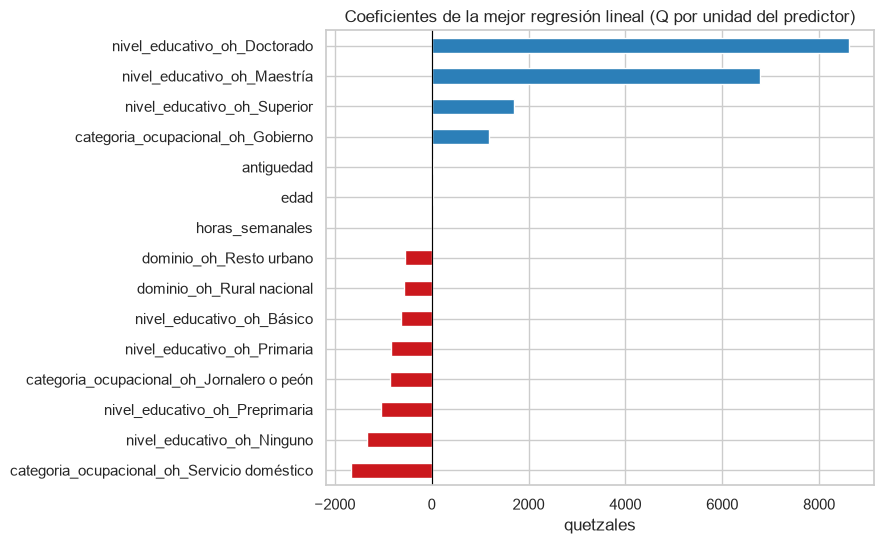

,coeficiente (Q)
edad,20.4
antiguedad,23.4
horas_semanales,16.2
nivel_educativo_oh_Doctorado,8619.7
nivel_educativo_oh_Preprimaria,-1049.1
nivel_educativo_oh_Maestría,6780.6
nivel_educativo_oh_Ninguno,-1333.4
nivel_educativo_oh_Superior,1694.4
nivel_educativo_oh_Básico,-631.2
nivel_educativo_oh_Primaria,-836.4


In [34]:
lr_final = mejor_lr.stages[-1]
coef = pd.Series(lr_final.coefficients.toArray(), index=nombres_features(mejor_lr.transform(validacion)))
print(f"intercepto: Q{lr_final.intercept:,.0f}")

fig, eje = plt.subplots(figsize=(9, 5.6))
coef.sort_values().plot.barh(ax=eje, color=np.where(coef.sort_values() > 0, "#2c7fb8", "#cb181d"))
eje.axvline(0, color="black", lw=0.8)
eje.set_title("Coeficientes de la mejor regresión lineal (Q por unidad del predictor)")
eje.set_xlabel("quetzales")
plt.tight_layout()
plt.show()
coef.round(1).to_frame("coeficiente (Q)")

Los coeficientes están en quetzales y cada uno describe una asociación manteniendo fijas las
demás variables, no un efecto causal. Los de edad, antigüedad y horas son por año o por hora y
por eso se ven casi en cero en la gráfica. Cada año de edad se asocia con Q20 más, cada año de
antigüedad con Q23 y cada hora semanal adicional con Q16. Las indicadoras se leen frente a la
categoría de referencia. Frente a diversificado, la maestría suma unos Q6 800, el doctorado Q8 600
y la educación superior Q1 700, mientras que básico, primaria, preprimaria y ninguno restan entre
Q630 y Q1 330. Frente a la empresa privada, el gobierno suma Q1 170 y el jornalero y el servicio
doméstico restan Q860 y Q1 660. Vivir fuera del área metropolitana resta unos Q560.

El orden coincide con lo que vimos en el ejercicio 2, pero el modelo impone una estructura
aditiva, por ejemplo supone que una hora más vale lo mismo en el gobierno que en el servicio
doméstico y que la prima de la maestría es la misma en cualquier dominio. El intercepto de Q2 458
corresponde a una persona de edad, antigüedad y horas cero, así que no tiene interpretación
propia.

In [35]:
metricas_lr = pd.concat([
    referencia.xs("validación", level="conjunto").drop(columns="predicción"),
    pd.DataFrame([metricas(mejor_lr.transform(validacion))], index=["regresión lineal"])])
metricas_lr["mejora RMSE vs media (%)"] = 100 * (1 - metricas_lr["rmse"] / metricas_lr.loc["referencia (media)", "rmse"])
metricas_lr["mejora MAE vs mediana (%)"] = 100 * (1 - metricas_lr["mae"] / metricas_lr.loc["referencia (mediana)", "mae"])

mejor_lr.write().overwrite().save(str(MODELOS / "regresion_lineal"))
print("modelo guardado en", MODELOS / "regresion_lineal")
metricas_lr.round(3)

modelo guardado en /Users/ferahmz/Documents/uvg/octavo/Data Science/Lab7_DS/modelos/regresion_lineal


,mae,rmse,r2,mejora RMSE vs media (%),mejora MAE vs mediana (%)
referencia (media),1672.503,2889.571,-0.003,0.000,-0.126
referencia (mediana),1670.390,2936.004,-0.036,-1.607,0.000
regresión lineal,1210.137,2186.420,0.426,24.334,27.554


La regresión lineal mejora con claridad a la referencia. En validación baja el MAE de Q1 670 a
Q1 210, un 28 por ciento menos que la mediana, y el RMSE de Q2 890 a Q2 186, un 24 por ciento menos
que la media, con un R² de 0.43. Aun así explica menos de la mitad de la variación del salario y un
error típico de Q1 200 equivale a cerca del 40 por ciento del salario mediano. El RMSE casi duplica
al MAE, señal de que unos pocos errores muy grandes, en salarios altos que llegan a Q60 000 en
validación, pesan mucho. No recortamos esos salarios, como pide el enunciado, así que su efecto
queda en las métricas y lo revisaremos en el análisis de errores.

## Ejercicio 6. Pipeline de Random Forest

Usamos las mismas etapas comunes y los mismos conjuntos de entrenamiento y validación, y
agregamos un RandomForestRegressor. Los árboles dividen por umbrales sobre cada variable, así que
la escala de los predictores no cambia sus decisiones y no estandarizamos. Probamos una grilla de
numTrees, la cantidad de árboles que se promedian, y maxDepth, la profundidad máxima de cada
árbol, siempre con la misma semilla. Registramos también las métricas de entrenamiento para ver
si los árboles más profundos se ajustan de más.

In [36]:
import time


def pipeline_rf(numTrees, maxDepth):
    rf = RandomForestRegressor(featuresCol="features", labelCol=OBJETIVO, numTrees=numTrees,
                               maxDepth=maxDepth, seed=SEMILLA)
    return Pipeline(stages=etapas_comunes() + [rf])


GRILLA_RF = [{"numTrees": n, "maxDepth": d} for n in [50, 150] for d in [5, 10, 15]]

filas, modelos_rf = [], []
for cfg in GRILLA_RF:
    inicio = time.time()
    modelo = pipeline_rf(**cfg).fit(entrenamiento)
    segundos = time.time() - inicio
    modelos_rf.append(modelo)
    m_tr = metricas(modelo.transform(entrenamiento))
    m_va = metricas(modelo.transform(validacion))
    filas.append({**cfg, **{f"{k}_train": v for k, v in m_tr.items()},
                  **{f"{k}_valid": v for k, v in m_va.items()}, "segundos": segundos})
resultados_rf = pd.DataFrame(filas)
i_rf = resultados_rf["rmse_valid"].idxmin()
mejor_cfg_rf = GRILLA_RF[i_rf]
mejor_rf = modelos_rf[i_rf]
print("mejor configuración por RMSE de validación:", mejor_cfg_rf)
resultados_rf.round(3)

mejor configuración por RMSE de validación: {'numTrees': 150, 'maxDepth': 15}


,numTrees,maxDepth,mae_train,rmse_train,r2_train,mae_valid,rmse_valid,r2_valid,segundos
0,50,5,1205.568,2220.738,0.416,1188.344,2181.990,0.428,0.918
1,50,10,1081.076,1962.490,0.544,1084.027,2004.194,0.517,1.875
2,50,15,1001.821,1800.456,0.616,1049.110,1932.479,0.551,7.542
3,150,5,1200.497,2219.293,0.417,1185.320,2183.073,0.427,1.070
4,150,10,1080.026,1967.324,0.542,1082.284,2004.068,0.517,5.963
5,150,15,995.779,1790.009,0.621,1044.881,1921.490,0.556,31.788


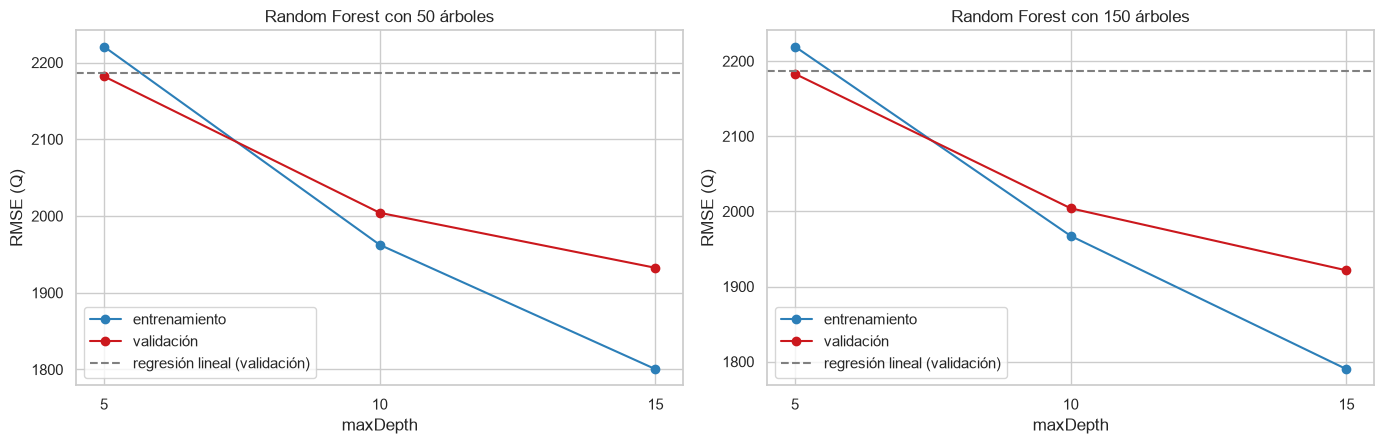

In [37]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4.6))
for eje, n in zip(ejes, [50, 150]):
    t = resultados_rf[resultados_rf["numTrees"] == n]
    eje.plot(t["maxDepth"], t["rmse_train"], "-o", color="#2c7fb8", label="entrenamiento")
    eje.plot(t["maxDepth"], t["rmse_valid"], "-o", color="#cb181d", label="validación")
    eje.axhline(resultados_lr.loc[i_lr, "rmse_valid"], color="gray", ls="--",
                label="regresión lineal (validación)")
    eje.set_title(f"Random Forest con {n} árboles")
    eje.set_xlabel("maxDepth")
    eje.set_ylabel("RMSE (Q)")
    eje.set_xticks([5, 10, 15])
    eje.legend()
plt.tight_layout()
plt.show()

La profundidad es lo que más cambia el resultado. Con maxDepth = 5 el bosque rinde igual que la
regresión lineal, RMSE de validación cercano a Q2 180. Con 10 baja a unos Q2 004 y con 15 a Q1 921,
el mejor valor. Pasar de 50 a 150 árboles apenas cambia el error, de Q1 932 a Q1 921 con
profundidad 15, porque promediar más árboles reduce la varianza pero no el sesgo, a cambio de
multiplicar el tiempo de ajuste, de 6 a 23 segundos.

La gráfica muestra también que la brecha entre entrenamiento y validación crece con la
profundidad. Con 5 niveles el error de validación es incluso menor que el de entrenamiento, y con
15 el de entrenamiento baja a Q1 790 mientras el de validación queda en Q1 921. El bosque empieza a
memorizar parte de los datos, pero la validación sigue mejorando, así que la profundidad 15 todavía
compensa. Es el borde de la grilla. Probamos maxDepth = 20 con 150 árboles y el ajuste agotó los
4 GB de memoria del driver, porque la cantidad de nodos puede duplicarse con cada nivel, así que
nos quedamos con 15. La mejor configuración es numTrees = 150 y maxDepth = 15 con semilla 23748.

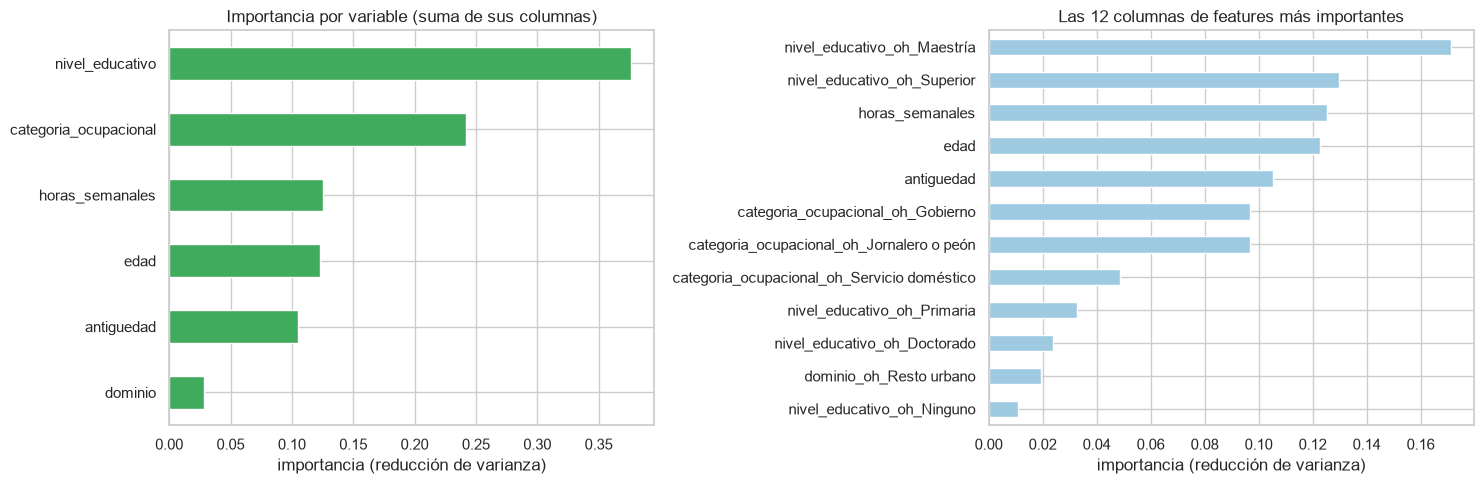

,importancia
nivel_educativo,0.377
categoria_ocupacional,0.242
horas_semanales,0.125
edad,0.123
antiguedad,0.105
dominio,0.028


In [38]:
importancia = pd.Series(mejor_rf.stages[-1].featureImportances.toArray(),
                        index=nombres_features(mejor_rf.transform(validacion)))
# se suman las indicadoras de cada variable categórica para comparar las seis variables
por_variable = pd.Series({v: importancia[[n for n in importancia.index if n == v or n.startswith(f"{v}_oh")]].sum()
                          for v in NUM_PRED + CAT_PRED}).sort_values()

fig, ejes = plt.subplots(1, 2, figsize=(15, 5))
por_variable.plot.barh(ax=ejes[0], color="#41ab5d")
ejes[0].set_title("Importancia por variable (suma de sus columnas)")
importancia.sort_values().tail(12).plot.barh(ax=ejes[1], color="#9ecae1")
ejes[1].set_title("Las 12 columnas de features más importantes")
for eje in ejes:
    eje.set_xlabel("importancia (reducción de varianza)")
plt.tight_layout()
plt.show()
por_variable.sort_values(ascending=False).round(3).to_frame("importancia")

El nivel educativo es la variable más importante, con el 38 por ciento de la reducción de
varianza, seguido de la categoría ocupacional con el 24. Horas, edad y antigüedad aportan entre
10 y 13 por ciento cada una y el dominio apenas un 3. Coincide con el ejercicio 2, donde la
educación y la categoría separaban mucho más los salarios que las variables numéricas, cuya
correlación con el salario era débil. Por columna, las indicadoras de maestría y educación
superior son las que más reducen el error, porque separan el grupo de salarios altos. La
importancia mide cuánto ayuda cada variable a dividir los datos de entrenamiento, no el signo ni
la causa de la relación, y tiende a favorecer a las variables continuas, que ofrecen más puntos de
corte.

### Comparación en validación

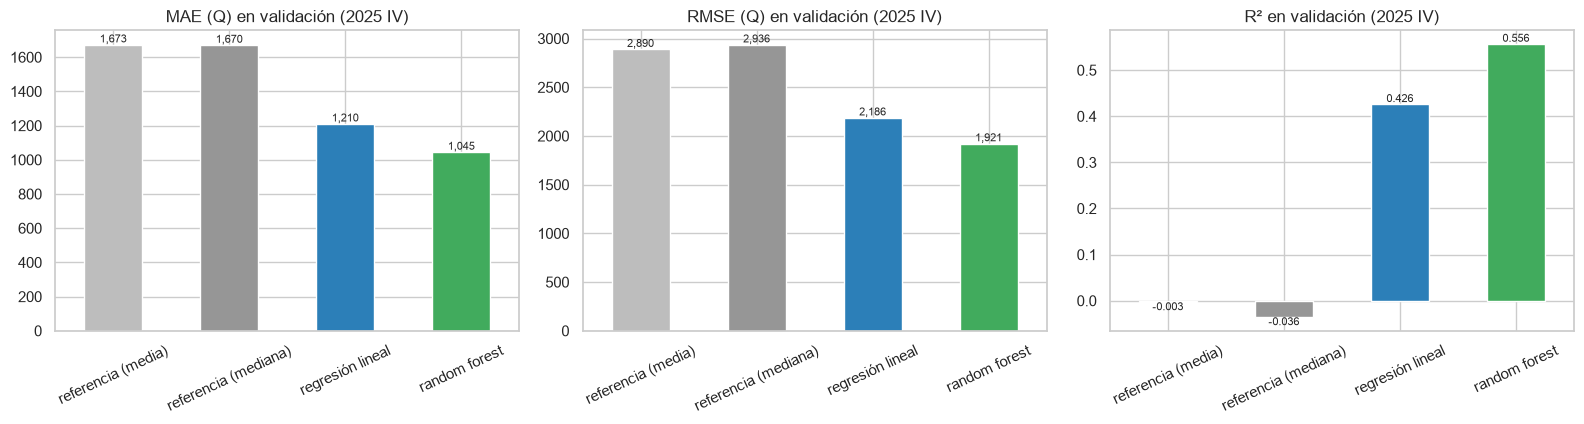

modelo guardado en /Users/ferahmz/Documents/uvg/octavo/Data Science/Lab7_DS/modelos/random_forest
configuraciones elegidas para el ejercicio 7:
  regresión lineal: {'regParam': 0.0, 'elasticNetParam': 0.0}
  random forest:    {'numTrees': 150, 'maxDepth': 15}


,mae,rmse,r2
referencia (media),1672.503,2889.571,-0.003
referencia (mediana),1670.390,2936.004,-0.036
regresión lineal,1210.137,2186.420,0.426
random forest,1044.881,1921.490,0.556


In [39]:
comparacion_valid = pd.concat([
    referencia.xs("validación", level="conjunto").drop(columns="predicción"),
    pd.DataFrame([metricas(mejor_lr.transform(validacion)),
                  metricas(mejor_rf.transform(validacion))],
                 index=["regresión lineal", "random forest"])])

fig, ejes = plt.subplots(1, 3, figsize=(16, 4.4))
colores = ["#bdbdbd", "#969696", "#2c7fb8", "#41ab5d"]
for eje, m, titulo in zip(ejes, METRICAS, ["MAE (Q)", "RMSE (Q)", "R²"]):
    comparacion_valid[m].plot.bar(ax=eje, color=colores)
    eje.set_title(f"{titulo} en validación (2025 IV)")
    eje.tick_params(axis="x", rotation=25)
    for i, v in enumerate(comparacion_valid[m]):
        eje.text(i, v, f"{v:,.3f}" if m == "r2" else f"{v:,.0f}", ha="center",
                 va="bottom" if v >= 0 else "top", fontsize=8)
plt.tight_layout()
plt.show()

mejor_rf.write().overwrite().save(str(MODELOS / "random_forest"))
print("modelo guardado en", MODELOS / "random_forest")
print("configuraciones elegidas para el ejercicio 7:")
print("  regresión lineal:", mejor_cfg_lr)
print("  random forest:   ", mejor_cfg_rf)
comparacion_valid.round(3)

Random Forest gana en las tres métricas de validación. Frente a la regresión lineal baja el MAE
de Q1 210 a Q1 045 y el RMSE de Q2 186 a Q1 921, entre 12 y 14 por ciento menos, y sube el R² de
0.43 a 0.56. Frente a la referencia de la media reduce el RMSE en un 34 por ciento.

La diferencia viene de la forma de cada modelo. La regresión lineal suma efectos fijos, cada año,
hora o categoría mueve el salario siempre en la misma cantidad. El bosque parte los datos por
umbrales y combina variables, así que puede captar relaciones no lineales, como un salario que
sube con la edad y después se estanca, e interacciones, como que la prima de la maestría o el
valor de una hora extra dependan de la categoría ocupacional. Con solo seis predictores y más de
40 000 registros hay datos suficientes para aprovechar esa flexibilidad sin sobreajustar
demasiado. A cambio el bosque es menos interpretable, pesa más y ya muestra una brecha entre
entrenamiento y validación.

Ninguno de los dos es muy preciso. Un R² de 0.56 deja sin explicar casi la mitad de la variación,
porque el salario depende de cosas que no están entre los seis predictores, como la ocupación
concreta, la empresa o la región. En los dos modelos el RMSE es casi el doble del MAE, así que los
salarios altos siguen concentrando los errores grandes.

Para el ejercicio 7 quedan elegidas la regresión lineal sin regularizar y el Random Forest con
150 árboles y profundidad 15. Los dos pipelines están guardados en la carpeta modelos, y para
reentrenarlos con los cuatro trimestres de 2025 basta con
`pipeline_lr(**mejor_cfg_lr).fit(eneic_2025)` y `pipeline_rf(**mejor_cfg_rf).fit(eneic_2025)`.

## Ejercicio 7. Entrenamiento final y evaluación en 2026

Con una configuración elegida por algoritmo, la regresión lineal sin regularizar y el Random
Forest de 150 árboles y profundidad 15, reentrenamos cada pipeline completo, incluidas las etapas
de StringIndexer y OneHotEncoder, con los cuatro trimestres de 2025. El IV de 2025 ya cumplió su
papel de validación y ahora aporta más datos al ajuste final. Los hiperparámetros no se vuelven a
tocar.

El conjunto de prueba es el primer trimestre de 2026, preparado en el ejercicio 1 con exactamente
los mismos filtros, en el mismo orden, y las mismas reglas de etiquetado que 2025. Es la primera
vez que un modelo lo ve. Antes de predecir comprobamos que no traiga categorías ausentes en 2025.

In [40]:
prueba = eneic_2026.cache()
print(f"registros elegibles de prueba (2026-I): {prueba.count():,}")
print(f"registros de entrenamiento final (2025 I-IV): {eneic_2025.count():,}")
for c in CAT_PRED:
    nuevas = (prueba.select(c).distinct()
              .join(eneic_2025.select(c).distinct(), on=c, how="left_anti").count())
    print(f"{c:22s} categorías nuevas en 2026: {nuevas}")
resumen_objetivo_2026 = pd.DataFrame({"2025 completo": resumen_objetivo(eneic_2025),
                                      "prueba 2026-I": resumen_objetivo(prueba)}).T
resumen_objetivo_2026.round(1)

registros elegibles de prueba (2026-I): 13,258
registros de entrenamiento final (2025 I-IV): 53,025
nivel_educativo        categorías nuevas en 2026: 0


categoria_ocupacional  categorías nuevas en 2026: 0


dominio                categorías nuevas en 2026: 0


,registros,media,mediana,p95,max
2025 completo,53025.0,3421.7,3000.0,8000.0,99000.0
prueba 2026-I,13258.0,3565.8,3200.0,8000.0,60000.0


Los 13 258 registros de prueba pasaron por los mismos filtros que 2025 y no traen categorías
nuevas, así que los StringIndexer ajustados con 2025 pueden codificarlos todos. El salario de 2026
es algo mayor que el de 2025, con mediana de Q3 200 frente a Q3 000 y media de Q3 566 frente a
Q3 422, y el máximo es Q60 000. Ese aumento sigue la tendencia entre trimestres que vimos en el
ejercicio 2 y es parte de lo que la prueba mide, si un modelo ajustado con 2025 sigue sirviendo en
un trimestre posterior.

In [41]:
final_lr = pipeline_lr(**mejor_cfg_lr).fit(eneic_2025)
final_rf = pipeline_rf(**mejor_cfg_rf).fit(eneic_2025)
final_lr.write().overwrite().save(str(MODELOS / "regresion_lineal_final"))
final_rf.write().overwrite().save(str(MODELOS / "random_forest_final"))

# referencia recalculada con el mismo conjunto de entrenamiento final
media_2025 = eneic_2025.select(F.mean(OBJETIVO)).first()[0]
mediana_2025 = eneic_2025.select(F.percentile_approx(OBJETIVO, 0.5, 100000)).first()[0]

# las dos predicciones se unen por la clave única para garantizar los mismos registros
predicciones = (final_lr.transform(prueba)
    .select(*CLAVE, OBJETIVO, "nivel_educativo", "categoria_ocupacional", "dominio",
            F.col("prediction").alias("pred_lr"))
    .join(final_rf.transform(prueba).select(*CLAVE, F.col("prediction").alias("pred_rf")),
          on=CLAVE, how="inner")
    .withColumn("pred_media", F.lit(media_2025))
    .withColumn("pred_mediana", F.lit(mediana_2025))
    .cache())
n_pred = predicciones.count()
assert n_pred == prueba.count(), "los modelos no se evaluaron sobre los mismos registros"
print(f"registros con predicción de ambos modelos: {n_pred:,}")

MODELOS_EVAL = {"referencia (media)": "pred_media", "referencia (mediana)": "pred_mediana",
                "regresión lineal": "pred_lr", "random forest": "pred_rf"}
metricas_prueba = pd.DataFrame({nombre: metricas(predicciones, col)
                                for nombre, col in MODELOS_EVAL.items()}).T
metricas_prueba["mejora RMSE vs media (%)"] = 100 * (1 - metricas_prueba["rmse"] / metricas_prueba.loc["referencia (media)", "rmse"])
metricas_prueba["mejora MAE vs mediana (%)"] = 100 * (1 - metricas_prueba["mae"] / metricas_prueba.loc["referencia (mediana)", "mae"])
print(f"referencias: media Q{media_2025:,.1f}, mediana Q{mediana_2025:,.1f}")
neg = predicciones.agg(F.min("pred_lr"), F.sum((F.col("pred_lr") < 0).cast("int"))).first()
print(f"regresión lineal: predicción mínima Q{neg[0]:,.1f}, predicciones negativas: {neg[1]}")
metricas_prueba.round(3)

registros con predicción de ambos modelos: 13,258


referencias: media Q3,421.7, mediana Q3,000.0
regresión lineal: predicción mínima Q-495.6, predicciones negativas: 29


,mae,rmse,r2,mejora RMSE vs media (%),mejora MAE vs mediana (%)
referencia (media),1718.086,2871.421,-0.003,0.000,0.034
referencia (mediana),1718.678,2923.083,-0.039,-1.799,0.000
regresión lineal,1240.711,2163.752,0.431,24.645,27.810
random forest,1076.898,1903.050,0.560,33.724,37.342


Los dos modelos se evaluaron sobre exactamente los mismos 13 258 registros, unidos por la clave
periodo_archivo, NUM_HOGAR y NUM_PERSONA. La referencia se recalculó con los cuatro trimestres de
2025, la misma base del ajuste final, y predice Q3 422 para todos.

En la prueba, Random Forest vuelve a ser el mejor modelo en las tres métricas. Su MAE es Q1 077, un
37 por ciento menor que el de la referencia de la mediana, y su RMSE Q1 903, un 34 por ciento menor
que el de la referencia de la media, con un R² de 0.56. La regresión lineal queda en medio, con MAE
de Q1 241, RMSE de Q2 164 y R² de 0.43. Frente a la regresión lineal, el bosque reduce el MAE en un
13 por ciento y el RMSE en un 12 por ciento. Las referencias tienen un R² un poco negativo porque su
constante viene de 2025 y el salario medio de 2026 es más alto.

La regresión lineal produce además algunas predicciones negativas, un salario imposible, porque su
forma aditiva permite que varias indicadoras negativas sumen más que el intercepto. El bosque no
tiene ese problema, porque cada predicción es un promedio de salarios observados en entrenamiento.

validación 2025-IV                  prueba 2026-I  \
                                    mae      rmse     r2           mae   
referencia (media)             1672.503  2889.571 -0.003      1718.086   
referencia (mediana)           1670.390  2936.004 -0.036      1718.678   
regresión lineal               1210.137  2186.420  0.426      1240.711   
random forest                  1044.881  1921.490  0.556      1076.898   

                                       
                          rmse     r2  
referencia (media)    2871.421 -0.003  
referencia (mediana)  2923.083 -0.039  
regresión lineal      2163.752  0.431  
random forest         1903.050  0.560

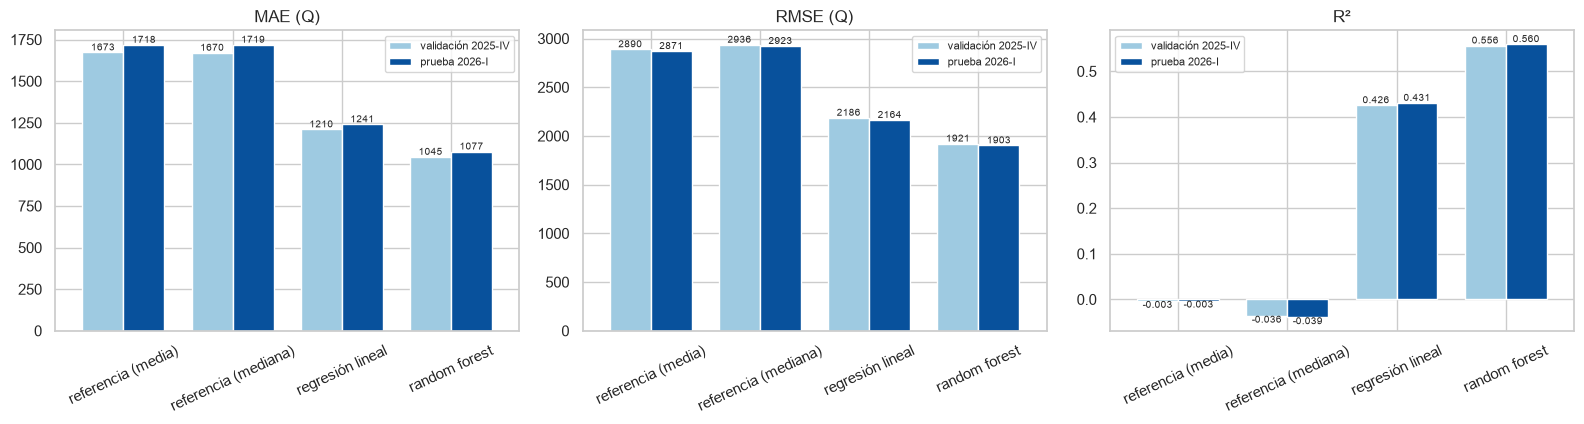

In [42]:
val_vs_prueba = pd.concat({"validación 2025-IV": comparacion_valid[METRICAS],
                           "prueba 2026-I": metricas_prueba[METRICAS]}, axis=1)
display(val_vs_prueba.round(3))

fig, ejes = plt.subplots(1, 3, figsize=(16, 4.4))
for eje, m, titulo in zip(ejes, METRICAS, ["MAE (Q)", "RMSE (Q)", "R²"]):
    t = val_vs_prueba.xs(m, axis=1, level=1)
    t.plot.bar(ax=eje, color=["#9ecae1", "#08519c"], width=0.75)
    eje.set_title(titulo)
    eje.tick_params(axis="x", rotation=25)
    eje.legend(fontsize=8)
    for cont in eje.containers:
        eje.bar_label(cont, fmt="%.3f" if m == "r2" else "%.0f", fontsize=7)
plt.tight_layout()
plt.show()

El desempeño en 2026 es prácticamente el mismo que en la validación de 2025. El MAE sube unos Q30
en los dos modelos, en parte porque los salarios de 2026 son algo mayores, mientras que el RMSE baja
un poco y el R² queda igual o apenas mayor, 0.43 y 0.56. No hay señales de que la selección de
hiperparámetros con el IV de 2025 se haya ajustado de más a ese trimestre, y el orden de los modelos
se mantiene, Random Forest, regresión lineal y referencia. Los resultados de la validación eran una
buena estimación del error en datos nuevos.

Aun así, ninguno de los dos modelos es preciso a nivel individual. Un MAE de Q1 077 equivale a
un tercio del salario mediano de 2026, y un R² de 0.56 deja sin explicar casi la mitad de la
variación. Los seis predictores describen a la persona y su empleo solo a grandes rasgos.